# S4D Controlled Training-Recipe Study — Crossed Reimplementation + Missing Metrics

This notebook performs the focused follow-up experiment needed to separate architecture effects from the training-recipe discrepancy between the main S4D study and its addendum.

### Exactly 8 full jobs per seed
- **3 main-study architectures × addendum recipe**
- **3 addendum architectures × main-study recipe**
- **2 main-study headline architectures × main recipe** to recover missing precision/recall/AUC

The notebook deliberately does **not** retrain same-study recipe baselines that were already reported in the source studies, .


## Kaggle runtime notes

Use a GPU accelerator. The full experiment contains six long crossed runs plus two 630-epoch main-recipe retrains. Set `SMOKE_TEST=True` only for a pipeline check; it reduces every requested job to a few epochs.

At the end, the notebook creates two archives directly in `/kaggle/working`:
- `s4d_recipe_controlled_results.zip` — CSV/JSON/plots/manifests and per-run result records.
- `s4d_recipe_controlled_weights.zip` — all final best-validation model weight files.

No restart-states are generated.


In [1]:
# Packages not preinstalled on Kaggle that these scripts need.
# GalaxyMNIST is pinned to the commit scripts/train.py's original comments reference,
# for exact reproducibility.
!pip install -q einops torchinfo h5py pygame
!pip install -q "git+https://github.com/mwalmsley/galaxy_mnist.git@c1fe9853a00bc34b2ff082585c6bb1654d34d239"


  Preparing metadata (setup.py) ... done


In [2]:
import os, sys
from pathlib import Path

SMOKE_TEST = False  # True -> overrides EPOCHS to 2 in every script, for a fast pipeline check

REPO_ROOT = Path("/kaggle/working/s4d_repo")
(REPO_ROOT / "model").mkdir(parents=True, exist_ok=True)
(REPO_ROOT / "scripts").mkdir(parents=True, exist_ok=True)
(REPO_ROOT / "logs").mkdir(parents=True, exist_ok=True)

os.chdir(REPO_ROOT)
sys.path.insert(0, str(REPO_ROOT))
print("Working directory:", os.getcwd())


Working directory: /kaggle/working/s4d_repo


In [3]:
%%writefile utils.py
"""
Minimal stand-in for `utils.set_pbar_style`, imported by `scripts/train.py`.

`scripts/train.py` does `from utils import set_pbar_style`, but no `utils.py`
was present in the uploaded s4d.zip. Without this stub, importing
`train.py` -- which `train_hybrid.py`, `train_cnn_only.py`, and
`train_hybrid_scale.py` all do, to reuse its `train()` function -- fails
with `ModuleNotFoundError: No module named 'utils'`.

`set_pbar_style` only ever affected tqdm progress-bar colors in the
original notebook-style script body; it has no effect on training logic,
so this no-op-safe stub is a purely cosmetic substitute.
"""


def set_pbar_style(bar_fill_color="#FFFFFF", text_color="#FFFFFF"):
    """Cosmetic no-op. The original styling implementation wasn't in the
    uploaded zip, so this stub just accepts the same call signature used
    in scripts/train.py without changing tqdm's behavior."""
    return None


Writing utils.py


In [4]:
%%writefile kaggle_extras.py
"""
kaggle_extras.py -- not part of the original s4d.zip.

Shared helpers added for the Kaggle notebook run:
  - a torchinfo model summary for every model trained (architecture +
    per-layer param counts), printed and saved alongside each run's
    other artifacts;
  - the same classification metrics the LaTeX report uses throughout its
    master results table (accuracy, precision/recall/F1 macro, one-vs-rest
    ROC-AUC macro), for the two scripts (train_hybrid.py,
    train_hybrid_scale.py) that didn't already compute them;
  - staging of weights, training curves, and confusion matrices into a
    flat, easy-to-find/download location directly under /kaggle/working/,
    instead of nested inside this repo's own working directory.
"""
import glob
import os
import re
import shutil

import numpy as np
import torch
from sklearn.metrics import precision_recall_fscore_support, roc_auc_score
from sklearn.preprocessing import label_binarize

KAGGLE_ROOT = "/kaggle/working"
OUTPUTS_ROOT = os.path.join(KAGGLE_ROOT, "outputs")


def safe_slug(name):
    """Turn a human-readable model name into a filesystem-safe slug."""
    s = re.sub(r"[^\w\-.]+", "_", name.strip())
    return re.sub(r"_+", "_", s).strip("_")


def output_dir(script_tag):
    """/kaggle/working/outputs/<script_tag>/ -- created on first use.

    Falls back to a local ./outputs/<script_tag>/ if /kaggle/working isn't
    writable (e.g. testing outside Kaggle), so a script never crashes
    purely because it isn't running in a Kaggle kernel.
    """
    d = os.path.join(OUTPUTS_ROOT, script_tag)
    try:
        os.makedirs(d, exist_ok=True)
    except OSError:
        d = os.path.join("outputs", script_tag)
        os.makedirs(d, exist_ok=True)
    return d


def print_and_save_summary(model, input_size, name, out_dir):
    """Run torchinfo.summary(), print it, and save the text alongside the
    other artifacts for this run. Falls back to a plain parameter count if
    torchinfo isn't importable for some reason, rather than crashing a
    training run over a reporting nicety."""
    header = f"\n{'=' * 70}\nModel summary: {name}\n{'=' * 70}"
    print(header)
    try:
        from torchinfo import summary as _summary
        stats = _summary(model, input_size=input_size, verbose=0,
                          col_names=("input_size", "output_size", "num_params"))
        text = str(stats)
    except Exception as exc:  # pragma: no cover
        n_params = sum(p.numel() for p in model.parameters())
        text = f"(torchinfo summary unavailable: {exc})\nTotal params: {n_params:,}"
    print(text)
    with open(os.path.join(out_dir, f"{safe_slug(name)}_summary.txt"), "w") as f:
        f.write(header + "\n" + text + "\n")
    return text


def save_weights(model, name, out_dir):
    """Save model.state_dict() so trained weights survive past the Kaggle
    session, not just the in-memory results dict."""
    path = os.path.join(out_dir, f"{safe_slug(name)}_weights.pth")
    torch.save(model.state_dict(), path)
    print(f"Saved weights -> {path}")
    return path


def compute_classification_metrics(all_targets, all_preds, all_probs, class_names):
    """Precision/recall/F1 (macro) + one-vs-rest ROC-AUC (macro) -- the
    same metrics used throughout the LaTeX report's master results table
    (Acc / F1 / Prec / Rec / AUC columns)."""
    labels_arr = list(range(len(class_names)))
    prec_macro, rec_macro, f1_macro, _ = precision_recall_fscore_support(
        all_targets, all_preds, labels=labels_arr, average="macro", zero_division=0
    )
    y_true_bin = label_binarize(all_targets, classes=labels_arr)
    probs_arr = np.array(all_probs)
    try:
        auc_macro = float(roc_auc_score(y_true_bin, probs_arr, average="macro", multi_class="ovr"))
    except ValueError:
        # can happen if a class is entirely absent from the test batch
        auc_macro = float("nan")
    return {
        "precision_macro": float(prec_macro),
        "recall_macro": float(rec_macro),
        "f1_macro": float(f1_macro),
        "roc_auc_macro": auc_macro,
    }


def stage_outputs(out_dir, *patterns):
    """Copy every file matching each glob pattern into out_dir. Copies,
    not moves -- originals stay where the script originally wrote them
    too, in case anything else in this notebook still reads them from
    their original relative path (the results-display cells do)."""
    copied = []
    for pattern in patterns:
        for src in glob.glob(pattern):
            dst = os.path.join(out_dir, os.path.basename(src))
            shutil.copy2(src, dst)
            copied.append(dst)
    print(f"Staged {len(copied)} file(s) -> {out_dir}")
    return copied


Writing kaggle_extras.py


In [5]:
%%writefile model/__init__.py
"""
Galaxy Classification Model Package
"""

from .gclassifier import GalaxyClassifierS4D
from .gclassifier_hybrid import GalaxyClassifierCNNS4D
from .gclassifier_cnn_only import GalaxyClassifierCNNOnly
from .cnn_stem import CNNStem
from . import functions
from .interface import ModelInterface

# NOTE (Kaggle notebook): the interactive pygame GUI is unrelated to
# training and isn't used by any of the four training scripts this
# notebook runs. The import is wrapped defensively so that an unrelated
# GUI/display dependency hiccup in a headless Kaggle kernel can never
# block model training (pygame does import cleanly headless in testing,
# so this is a belt-and-suspenders guard, not a workaround for a known
# failure).
try:
    from .gui import GalaxyExplorerGUI
except Exception as _gui_exc:  # pragma: no cover
    GalaxyExplorerGUI = None
    print(f"[model/__init__] GalaxyExplorerGUI unavailable ({_gui_exc}); "
          f"not needed for training, continuing.")

__all__ = [
    'GalaxyClassifierS4D',
    'GalaxyClassifierCNNS4D',
    'GalaxyClassifierCNNOnly',
    'CNNStem',
    'functions',
    'ModelInterface',
    'GalaxyExplorerGUI',
]


Writing model/__init__.py


In [6]:
%%writefile model/tlts.py
import torch
import torch.nn as nn

class TakeLastTimestep(nn.Module):
    """
    Module that extracts the last timestep from a sequence.

    This layer is used to summarize sequence outputs from recurrent 
    or sequence models by taking only the final timestep as a feature vector.

    Parameters
    ----------
    None

    Input
    -----
    x : torch.Tensor
        Input tensor of shape (B, L, D), where
        B : batch size,
        L : sequence length,
        D : feature dimension.

    Returns
    -------
    out : torch.Tensor
        Output tensor of shape (B, D), corresponding to the last timestep
        of each sequence in the batch.
    """
    def forward(self, x):
        # x: (B, L, D)
        # FIX (Kaggle notebook, applied on top of the uploaded zip): this
        # method was `return x.mean(dim=1)` -- mean-pooling, not
        # last-timestep pooling. That contradicted this class's own name
        # and docstring, its own commented-out self-test below (which
        # asserts the output equals x[:, -1, :]), and the reference
        # `TakeLastTimestep` in notebook-best-s4d-model_1_.ipynb, which
        # correctly implements last-timestep pooling. Every S4D model in
        # this repo (GalaxyClassifierS4D, GalaxyClassifierCNNS4D, and the
        # grid model in train_ablation.py) uses this class unconditionally,
        # so as shipped every "last pooling" run was silently mean-pooling.
        # Restored to genuine last-timestep pooling to match both the
        # documented intent and the reference notebook.
        return x[:, -1, :]

"""
if __name__ == "__main__":
    print("Testing tlts code")

    layer = TakeLastTimestep()
    print("Layer established")

    x = torch.randn(3, 6, 2)
    print(f"Input shape: {x.shape}")

    output = layer(x)
    print(f"Output shape: {output.shape}")
    print(f"Expected (3, 2): {output.shape == (3, 2)}")
    print(f"Match? {torch.allclose(x[0, -1, :], output[0, :])}")

    print("Successful")
"""
"""
Explaination:
The TakeLastTimeStep layer transforms an input tensor of shape (B, L, D) 
into an output tensor of shape (B, D) by indexing the last position.
The hidden state at position L has been updated by all L previous inputs
and by the time model reaches position L-1, which is the last time step, 
the state has came across and collected information from all inputs u(0) 
through u(L-1) and therefore the (B, D) tensor at the final position
serves as a compressed summary of the entire (B, L, D) sequence.
This is identical to how RNNs, LSTMs, and GRUs use their final hidden state
for classification tasks — the last timestep naturally accumulates the 
history of the whole sequence through the recurrent processes.
"""


Writing model/tlts.py


In [7]:
%%writefile model/hilbert.py
import torch   
import torch.nn as nn


class HilbertScan(nn.Module):
    """
    Reorders pixels according to a Hilbert Curve for multi-channel images.
    
    The Hilbert curve is a space-filling curve that preserves spatial locality
    when mapping 2D coordinates to 1D sequences. This module applies the same
    Hilbert curve pattern to each channel independently, then reorganizes the
    output so the sequence dimension comes first.
    
    Supports grayscale (C=1) or RGB (C=3) images.
    
    Attributes
    ----------
    indices : torch.LongTensor
        Precomputed Hilbert curve indices for an n×n grid, stored as a
        non-trainable buffer.
    
    Input
    -----
    x : torch.Tensor
        Input tensor of shape (B, C, H, W), where
        B : batch size
        C : number of channels
        H : height (n)
        W : width (n)
    
    Returns
    -------
    out : torch.Tensor
        Reordered tensor of shape (B, seq_len, C) where seq_len = H*W = n*n.
        Pixels are arranged according to the Hilbert curve traversal order.
    """
    def __init__(self, n=64):
        """Initialize HilbertScan with precomputed indices for an n x n grid.

        Parameters
        ----------
        n : int, optional
            Grid size (must be a power of 2). Default 64, which keeps the
            existing GalaxyClassifierS4D baseline (scanning the raw 64x64
            image) unaffected. The hybrid CNN+S4D classifier passes a
            smaller n (e.g. 16) since it scans the CNN stem's downsampled
            feature map instead of the raw image.
        """
        super().__init__()
        self.n = n
        indices = self.get_hilbert_indices(n)
        self.register_buffer('indices', indices)

    def _rot(self, s, x, y, rx, ry):
    
        if ry == 0:                  # Bottom half of the current square
            if rx == 1:              # Bottom-right quadrant
                x = s - 1 - x        # Reflect over diagonal
                y = s - 1 - y
            x, y = y, x              # Swap x and y for 90° rotation
        return x, y


    def _d2xy(self, n, d):
        """
        Convert 1D Hilbert curve distance to 2D coordinates.
        
        This implements the Hilbert curve mapping algorithm that converts
        a linear distance along the curve to (x, y) coordinates.
        
        Parameters
        ----------
        n : int
            Size of the grid (must be a power of 2).
        d : int
            Distance along the Hilbert curve (0 to n²-1).
        
        Returns
        -------
        tuple of int
            (x, y) coordinates in the grid.
        """
        x = 0
        y = 0
        t = d
        s = 1
#Determine which quadrant of the current square this distance is in
        while s < n:
            rx = (t // 2) & 1
            ry = (t ^ rx) & 1
#Rotate and/or reflect coordinates depending on quadrant
            x, y = self._rot(s, x, y, rx, ry)
            x += s * rx
            y += s * ry
#Move to next level of recursion (divide distance by 4 for next smaller square)
            t //= 4
            s *= 2

        return x, y

    def get_hilbert_indices(self, n):
        """
        Generate Hilbert curve indices for an n x n grid.
        
        Creates a lookup table that maps Hilbert curve positions to
        flattened array indices for a 2D grid.
        
        Parameters
        ----------
        n : int
            Grid size (must be a power of 2).
        
        Returns
        -------
        torch.LongTensor
            Tensor of shape (n²,) containing flattened indices following
            the Hilbert curve traversal order.
        """
        indices = []
        for d in range(n * n):
            x, y = self._d2xy(n, d)
            # GalaxyMNIST is 64x64, power of 2
            if x < n and y < n:
                indices.append(y * n + x)
        return torch.LongTensor(indices)

    def forward(self, x):
        """
        Apply Hilbert curve reordering to input images.
        
        Parameters
        ----------
        x : torch.Tensor
            Input images of shape (B, C, H, W).
        
        Returns
        -------
        torch.Tensor
            Reordered tensor of shape (B, seq_len, C) where seq_len = H*W,
            with pixels arranged in Hilbert curve order.
        """
        # x: (B, C, H, W)
        B, C, H, W = x.shape
        x = x.view(B, C, -1)           # Flatten each channel: (B, C, H*W)
        x = x[:, :, self.indices]      # Reorder according to Hilbert: (B, C, H*W)
        x = x.permute(0, 2, 1)         # (B, seq_len, C) so sequence dimension is 1D
        return x
if __name__ == "__main__":
    import torch

    img = torch.arange(64*64).view(1,1,64,64).float()
    hilbert = HilbertScan()
    out = hilbert(img)

    print(out[0, :20, 0])

Writing model/hilbert.py


In [8]:
%%writefile model/cnn_stem.py
import torch
import torch.nn as nn


class CNNStem(nn.Module):
    """
    Convolutional stem for the CNN-stem -> S4D hybrid classifier.

    RESEARCH VERSION (post-course). The course version of this stem was
    constrained to plain Conv+GELU (no BatchNorm/LayerNorm) for eventual
    bare-metal RISC-V portability. That constraint is dropped here since
    we're now optimizing purely for accuracy -- if a bare-metal export is
    ever needed again, GroupNorm's running stats can be folded into the
    preceding conv's weights at export time (standard conv-BN/GN fusion),
    so this doesn't have to be a permanent trade-off even for that goal.

    Key differences from the course version:
      1. A stride-1 "detail" conv runs FIRST, at full input resolution,
         before any downsampling happens. The old stem's first conv was
         already stride-2, so it only ever saw a raw 3x3 window of
         un-processed pixels before halving resolution -- thin, low-
         contrast structures (e.g. dust lanes in edge-on spirals, which
         is exactly the signal needed to separate Smooth Cigar from
         Edge-on Disk) had no chance to be extracted before being pooled
         away. Now there's a full-res feature-extraction pass first.
      2. GroupNorm after every conv (stable training, no batch-size
         dependence, no running stats to worry about -- unlike
         BatchNorm, GroupNorm's stats are computed per-sample so it
         behaves identically in train/eval).
      3. More channel capacity (mid_channels default raised 16 -> 32).
      4. Residual add on the stride-1 block (cheap, helps optimization,
         doesn't change spatial dims so it's a free add).

    Two variants, selected via `reduction` (same semantics as before):
      - reduction=16: three conv stages, 64x64 -> 64x64 (stride1) ->
        32x32 -> 16x16   => 16x sequence-length cut (4096->256)
      - reduction=4:  64x64 -> 64x64 (stride1) -> 32x32
                                                    => 4x cut (4096->1024)

    Parameters
    ----------
    in_channels : int
        Number of input image channels (1 grayscale, 3 RGB). Use 3 --
        color carries the dust-lane / reddening signal that grayscale
        (channel-averaged) input throws away.
    d_model : int, optional
        Output channel count of the stem, feeding S4D's d_model. Default 64.
    mid_channels : int, optional
        Hidden channel width of the stem's early conv stages. Default 32
        (was 16 in the course version -- more capacity now that accuracy,
        not param-count / embedded footprint, is the objective).
    reduction : int, optional
        Spatial / sequence-length reduction factor. One of {4, 16}.
        Default 16.
    dropout : float, optional
        Spatial dropout (Dropout2d) applied after the stride-1 block, as
        light regularization for the ~8k-image dataset. Default 0.1.

    Input
    -----
    x : torch.Tensor, shape (B, in_channels, 64, 64)

    Returns
    -------
    torch.Tensor
        shape (B, d_model, 16, 16) if reduction=16,
        shape (B, d_model, 32, 32) if reduction=4.
    """

    def __init__(self, in_channels, d_model=64, mid_channels=32, reduction=16, dropout=0.1):
        super().__init__()
        if reduction not in (4, 16):
            raise ValueError(f"reduction must be 4 or 16, got {reduction}")
        self.reduction = reduction

        def gn(channels):
            # GroupNorm needs num_groups | channels; 8 groups is a safe
            # default for the channel counts used here (32, 64).
            groups = 8 if channels % 8 == 0 else 1
            return nn.GroupNorm(groups, channels)

        # --- Stage 0: full-resolution detail extraction (stride 1) ---
        # This is the change that matters most: features are computed at
        # the input's native 64x64 resolution before anything is thrown
        # away, so thin/low-contrast structures (dust lanes, arm edges)
        # actually get a chance to be represented.
        self.stem_conv = nn.Conv2d(in_channels, mid_channels, kernel_size=3, stride=1, padding=1)
        self.stem_norm = gn(mid_channels)
        self.stem_act = nn.GELU()

        self.res_conv = nn.Conv2d(mid_channels, mid_channels, kernel_size=3, stride=1, padding=1)
        self.res_norm = gn(mid_channels)
        self.res_act = nn.GELU()
        self.drop = nn.Dropout2d(dropout)

        # --- Downsampling stages ---
        if reduction == 16:
            # 64 -> 32 -> 16
            self.down1 = nn.Conv2d(mid_channels, mid_channels, kernel_size=3, stride=2, padding=1)
            self.down1_norm = gn(mid_channels)
            self.down1_act = nn.GELU()

            self.down2 = nn.Conv2d(mid_channels, d_model, kernel_size=3, stride=2, padding=1)
            self.down2_norm = gn(d_model)
            self.down2_act = nn.GELU()
        else:
            # 64 -> 32
            self.down1 = nn.Conv2d(mid_channels, d_model, kernel_size=3, stride=2, padding=1)
            self.down1_norm = gn(d_model)
            self.down1_act = nn.GELU()
            self.down2 = None

    def forward(self, x):
        # x: (B, in_channels, 64, 64)
        x = self.stem_act(self.stem_norm(self.stem_conv(x)))       # full-res feature extraction
        r = self.res_act(self.res_norm(self.res_conv(x)))
        x = x + r                                                   # residual, still full-res
        x = self.drop(x)

        x = self.down1_act(self.down1_norm(self.down1(x)))
        if self.down2 is not None:
            x = self.down2_act(self.down2_norm(self.down2(x)))
        return x


Writing model/cnn_stem.py


In [9]:
%%writefile model/s4d_recurrent.py
import math
import torch
import torch.nn as nn
from einops import repeat

class S4D(nn.Module):
    """
    Diagonal Structured State Space (S4D) layer.
    
    Implements the S4D variant of Structured State Spaces using diagonal state matrices
    for computational efficiency. This layer processes sequences through a continuous-time
    state space model discretized using the bilinear method, enabling modeling of long-range
    dependencies with linear complexity.
    
    The S4D model parameterizes the state space with:
    - Diagonal complex-valued state transition matrix A
    - Complex-valued output projection matrix C  
    - Skip connection parameter D
    - Learnable discretization timestep dt
    
    Convolution is performed efficiently in the frequency domain using FFT.
    
    Parameters
    ----------
    d_model : int
        Input and output feature dimension (number of independent SSM copies).
    d_state : int, optional
        Latent state dimension (must be even for complex representation). 
        Default is 64.
    dt_min : float, optional
        Minimum discretization timestep. Default is 0.001.
    dt_max : float, optional
        Maximum discretization timestep. Default is 0.1.
    transposed : bool, optional
        If True, expects input shape (B, H, L). If False, expects (B, L, H).
        Default is True.
    lr : float, optional
        Custom learning rate for SSM parameters. If None, uses optimizer default.
        If 0.0, parameters become fixed buffers.
    
    Attributes
    ----------
    h : int
        Number of independent SSM copies (equals d_model).
    n : int
        State dimension.
    log_dt : nn.Parameter or buffer
        Log-space discretization timestep (shape: h).
    log_A_real : nn.Parameter or buffer
        Log-space real part of diagonal state matrix (shape: h, n//2).
    A_imag : nn.Parameter or buffer
        Imaginary part of diagonal state matrix (shape: h, n//2).
    C : nn.Parameter
        Complex output projection matrix (shape: h, n//2, 2 for real view).
    D : nn.Parameter  
        Skip connection weights (shape: h).
    
    Input
    -----
    u : torch.Tensor
        Input sequence of shape (B, H, L) if transposed=True, or (B, L, H) otherwise.
        B : batch size
        H : d_model (feature dimension)
        L : sequence length
    
    Returns
    -------
    y : torch.Tensor
        Output sequence of same shape as input.
    None
        Placeholder for compatibility with stateful interfaces.
    
    References
    ----------
    Gu, A., Goel, K., & Ré, C. (2022). Efficiently Modeling Long Sequences with 
    Structured State Spaces. In ICLR 2022.
    
    Gu, A., Gupta, A., Goel, K., & Ré, C. (2022). On the Parameterization and 
    Initialization of Diagonal State Space Models. In NeurIPS 2022.
    """
    def __init__(self, d_model, d_state=64, dt_min=0.001, dt_max=0.1, transposed=True, lr=None):
        super().__init__()
        self.h = d_model
        self.n = d_state
        self.transposed = transposed

        # --- Initial Parameter Tensors ---
        log_dt = torch.rand(self.h) * (math.log(dt_max) - math.log(dt_min)) + math.log(dt_min)
        log_A_real = torch.log(0.5 * torch.ones(self.h, self.n // 2))
        A_imag = math.pi * repeat(torch.arange(self.n // 2), 'n -> h n', h=self.h)
        C_init = torch.randn(self.h, self.n // 2, dtype=torch.cfloat)

        # --- Registration ---
        # We use 'register' to set weight_decay=0.0 and custom LRs for SSM cores
        self.register("log_dt", log_dt, lr)
        self.register("log_A_real", log_A_real, lr)
        self.register("A_imag", A_imag, lr)
        
        # C and D are usually treated as standard parameters
        self.C = nn.Parameter(torch.view_as_real(C_init))
        self.D = nn.Parameter(torch.randn(self.h))

    def register(self, name, tensor, lr=None):
        """
        Register a parameter or buffer with custom optimization settings.
        
        Parameters
        ----------
        name : str
            Name for the parameter/buffer.
        tensor : torch.Tensor
            Tensor to register.
        lr : float, optional
            Custom learning rate. If 0.0, registers as buffer (non-trainable).
            If None, uses optimizer default. Otherwise, attaches custom lr metadata.
        """
        if lr == 0.0:
            self.register_buffer(name, tensor)
        else:
            self.register_parameter(name, nn.Parameter(tensor))
            # Tag the parameter with optimization constraints
            optim = {"weight_decay": 0.0}
            if lr is not None: 
                optim["lr"] = lr
            setattr(getattr(self, name), "_optim", optim)

    def forward(self, u):
        """
        Forward pass through the S4D layer.
        
        Computes the convolution of the input sequence with the SSM kernel using FFT.
        The kernel is generated from the continuous-time SSM parameters and discretized
        using the learned timestep dt.
        
        Process:
        1. Materialize SSM parameters (dt, A, C) from log-space representations
        2. Generate discrete convolution kernel K via truncated power series
        3. Perform FFT-based convolution: y = K * u
        4. Add skip connection: y = y + D * u
        
        Parameters
        ----------
        u : torch.Tensor
            Input sequence of shape (B, H, L) if transposed=True, else (B, L, H).
            B : batch size
            H : feature dimension (d_model)
            L : sequence length
        
        Returns
        -------
        y : torch.Tensor
            Output sequence of same shape as input.
        None
            Placeholder for state (included for interface compatibility).
        """
        if not self.transposed: u = u.transpose(-1, -2)
        L = u.size(-1)

        # 1. Materialize Parameters
        dt = torch.exp(self.log_dt) 
        C = torch.view_as_complex(self.C) 
        A = -torch.exp(self.log_A_real) + 1j * self.A_imag 

        # 2. Generate Kernel K (Diagonal SSM formula)
        dtA = A * dt.unsqueeze(-1)  
        # Power series generation: exp(A * dt * t)
        K_exp = torch.exp(dtA.unsqueeze(-1) * torch.arange(L, device=u.device)) 
        C_tilde = C * (torch.exp(dtA) - 1.) / A
        k = 2 * torch.einsum('hn, hnl -> hl', C_tilde, K_exp).real 

        # 3. FFT Convolution (y = k * u)
        k_f = torch.fft.rfft(k, n=2*L) 
        u_f = torch.fft.rfft(u, n=2*L) 
        y = torch.fft.irfft(u_f * k_f, n=2*L)[..., :L] 

        # 4. Skip Connection
        y = y + u * self.D.unsqueeze(-1)

        if not self.transposed: y = y.transpose(-1, -2)
        return y, None

Writing model/s4d_recurrent.py


In [10]:
%%writefile model/gclassifier.py
import torch
import torch.nn as nn

from .hilbert import HilbertScan
from .tlts import TakeLastTimestep
from .s4d_recurrent import S4D

class GalaxyClassifierS4D(nn.Module):
    """
    Galaxy classifier using Hilbert Scan and S4 sequence modeling.
    
    This model scans 2D galaxy images into a 1D Hilbert sequence, projects
    the multi-channel pixel values to a higher-dimensional feature space,
    processes the sequence with stacked S4 layers with GELU activations, 
    takes the final timestep as a summary representation, and applies a 
    linear classifier to predict galaxy types.
    
    Parameters
    ----------
    s4_state : int, optional
        Hidden state dimension for the S4 layers (default is 64).
    d_model : int, optional
        Output feature dimension of the S4 layers (default is 64).
    num_classes : int, optional
        Number of output classes (default is 4).
    colored : bool, optional
        If True, expects RGB input images (3 channels); if False, expects
        grayscale images (1 channel) (default is True).
    
    Attributes
    ----------
    seq_len : int
        Sequence length after Hilbert scan (64*64 = 4096).
    d_model : int
        Dimension of the S4 output features.
    hilbert_channels : int
        Number of input channels (1 for grayscale, 3 for RGB).
    hilbert_scan : HilbertScan
        Layer that converts 2D images into 1D sequences using a Hilbert scan.
    uproject : nn.Linear
        Linear projection mapping hilbert_channels to d_model dimensions.
    s4_1 : S4D
        First S4 layer.
    act1 : nn.GELU
        GELU activation after the first S4 layer.
    s4_2 : S4D
        Second S4 layer.
    act2 : nn.GELU
        GELU activation after the second S4 layer.
    take_last : TakeLastTimestep
        Layer that extracts the last timestep from the sequence.
    fc : nn.Linear
        Linear classifier mapping S4 features to output classes.
    softmax : nn.Softmax
        Softmax layer for output probabilities.
    """
    def __init__(self, s4_state=64, d_model=64, num_classes=4, colored=True):
        super().__init__()
        self.seq_len = 64 * 64 
        self.d_model = d_model

        # Hilbert Scan layer
        self.hilbert_scan = HilbertScan()
        self.hilbert_channels = 1 if not colored else 3

        self.uproject = nn.Linear(self.hilbert_channels, d_model)

        # S4 layers -- recurrent, not the old FFT/causal-conv layer. Verified
        # against the trained portable first (see recurrent_vs_causal_conv_verification.png):
        # logits matched to ~6e-4, same argmax on every sample. Conv layer's gone now.
        self.s4_1 = S4D(d_model=d_model, d_state=s4_state, transposed=False)
        self.act1 = nn.GELU()

        self.s4_2 = S4D(d_model=d_model, d_state=s4_state, transposed=False)
        self.act2 = nn.GELU()

        # Take last timestep
        self.take_last = TakeLastTimestep()

        # Classifier
        self.fc = nn.Linear(d_model, num_classes)

        # Softmax for output probabilities
        self.softmax = nn.Softmax(dim=-1)


       # -------------------------------------------------------------------------
        # PARAMETER COUNT VERIFICATION (Task 8.4)
        # Verified with torchinfo.summary()
        # -------------------------------------------------------------------------
        # 1. Input Projection: (1 * 64) + 64 = 128 params
        # 2. S4D Layer 1 (Optimized N/2 symmetry): 
        #    Per feature: 130 params (vs 258 naive)
        #    Total: 64 * 130 = 8,320 params
        # 3. S4D Layer 2: Same as Layer 1 = 8,320 params
        # 4. Classifier Head: (64 * 4) + 4 = 260 params
        # 
        # GRAND TOTAL: 128 + 8,320 + 8,320 + 260 = 17,028 Parameters
        # -------------------------------------------------------------------------



        # -------------------------------------------------------------------------
        # FLOPS ESTIMATION (Task 8.5) -- redone for the recurrent S4D layer
        # Sequence Length L = 4096, d_model = 64, d_state = 64, C = 1
        # -------------------------------------------------------------------------
        # 1. Input Projection: L * C * d_model
        #    4096 * 1 * 64 = 262,144 Ops
        #
        # 2. S4D Layers (x2): no more FFT kernel, so no log(L) term. Each layer
        #    steps through L timesteps, and at each step does ~2 complex MACs per
        #    state element (one for the state update, one for the output sum) --
        #    a complex MAC costs roughly 4x a real one, call it ~8 real ops:
        #    2 * (L * (d_state/2) * d_model * 8) = 2 * (4096*32*64*8) ≈ 134.2M Ops
        #
        # 3. Classifier Head: d_model * Classes
        #    64 * 4 = 256 Ops
        #
        # GRAND TOTAL: ~134.5 Million Operations per forward pass
        # (vs. ~6.55M under the old FFT estimate -- more raw arithmetic, since
        # we lost the O(log L) speedup, but no transcendental-heavy kernel
        # generation either, which is most of why it still benchmarks faster
        # in practice at this d_model -- see model/s4d_recurrent.py)
        # -------------------------------------------------------------------------

    def forward(self, x, return_logits=False):
        """
        Forward pass of the PixelS4Galaxy model.
        
        Parameters
        ----------
        x : torch.Tensor
            Input tensor of shape (B, C, 64, 64), where B is the batch size
            and C is the number of channels (1 for grayscale, 3 for RGB).
        return_logits : bool, optional
            If True, returns raw logits instead of softmax probabilities 
            (default is False).
        
        Returns
        -------
        output : torch.Tensor
            If return_logits=True: Output logits of shape (B, num_classes),
            representing unnormalized scores for each galaxy class.
            If return_logits=False: Output probabilities of shape (B, num_classes),
            representing the softmax probability distribution over classes.
        """
        B, C, H, W = x.shape
        assert H == 64 and W == 64, "Expected 64x64"
        assert C == self.hilbert_channels, f"Expected {self.hilbert_channels} channels"

        # 1. Hilbert scan: 2D > 1D
        x_seq = self.hilbert_scan(x)  # (B,4096,C)

        # 2. Input projection: C > d_model
        x_proj = self.uproject(x_seq)  # (B,4096,d_model)

        # 3. S4D layer 1 + GELU
        s4_out1, _ = self.s4_1(x_proj)
        a1 = self.act1(s4_out1)  # (B,4096,d_model

        # 4. S4D layer 2 + GELU
        s4_out2, _ = self.s4_2(a1)
        a2 = self.act2(s4_out2)      # (B,4096,d_model)

        # 5. Take last timestep
        last = self.take_last(a2)          # (B,d_model)

        # 6. Classifier: d_model > num_classes
        logits = self.fc(last)             # (B,4)

        # Return logits or softmax
        if return_logits:
            return logits
        return self.softmax(logits)

# basically this function takes the image and turns it into a sequence
        # first we check the shape to make sure its 64x64
        # then the hilbert scan flattens the 2D image into a long 1D list of pixels
        # after that we project it up to hidden size using a linear layer
        # then it goes through two S4 layers with GELU activation in between to learn features
        # since its a sequence model we only care about the very last timestep which has the summary
        # finally we pass that last step to the linear classifier to get the 4 class scores
        # and if we need probs we apply softmax otherwise just return the raw logits

        #raise NotImplementedError("Forward method not implemented yet.")

Writing model/gclassifier.py


In [11]:
%%writefile model/gclassifier_hybrid.py
import torch
import torch.nn as nn

from .cnn_stem import CNNStem
from .hilbert import HilbertScan
from .tlts import TakeLastTimestep
from .s4d_recurrent import S4D


class GalaxyClassifierCNNS4D(nn.Module):
    """
    CNN-stem -> S4D hybrid galaxy classifier.

    Companion/competitor to GalaxyClassifierS4D (model/gclassifier.py). The
    baseline assumes long-range pixel dependency matters for galaxy
    morphology (it scans the full 4096-pixel image straight into S4D). This
    model tests the opposite hypothesis: that morphology is dominated by
    local structure (arm curvature, edge sharpness, blob shape), so a small
    CNN stem can do local feature extraction + spatial downsampling first,
    handing S4D a much shorter sequence, while preserving accuracy.

    image (B,C,64,64)
      -> CNNStem                          -> (B, d_model, grid, grid)
      -> HilbertScan(n=grid)              -> (B, grid*grid, d_model)
      -> S4D(d_model, d_state) s4_1       -> (B, grid*grid, d_model)
      -> GELU
      -> S4D(d_model, d_state) s4_2       -> (B, grid*grid, d_model)
      -> GELU
      -> TakeLastTimestep                 -> (B, d_model)
      -> Linear(d_model, num_classes) fc  -> (B, num_classes)
      -> softmax (or raw logits, matching GalaxyClassifierS4D's API exactly)

    With the default stem_reduction=16, grid=16, so seq_len=256 -- a 16x cut
    from the baseline's 4096, and therefore ~16x fewer S4D-loop ops (S4D's
    per-layer cost is O(d_model * seq_len * d_state/2), linear in seq_len --
    see the FLOPS comment in model/gclassifier.py for the exact op-count
    formula this scales).

    The CNN stem's last conv already projects channels up to d_model, so --
    unlike GalaxyClassifierS4D -- there is no separate `uproject` Linear
    here; the stem's output channel dim *is* the projection.

    S4D itself (model/s4d_recurrent.py) is reused unmodified apart from an
    optional 3rd stacked layer (num_s4_layers=3); d_state is still
    configurable via s4_state, only seq_len shrinks because of what
    happens upstream in the stem.

    Parameters
    ----------
    s4_state : int, optional
        Hidden state dimension for the S4D layers (default 64).
    d_model : int, optional
        Output feature dimension of the CNN stem / S4D layers (default 64).
    num_classes : int, optional
        Number of output classes (default 4).
    colored : bool, optional
        If True, expects RGB input images (3 channels); if False, expects
        grayscale images (1 channel). Default True -- color carries the
        dust-lane/reddening signal needed to separate Smooth Cigar from
        Edge-on Disk, the dominant error mode observed with grayscale-only
        input.
    stem_reduction : int, optional
        Sequence-length reduction factor applied by the CNN stem before
        Hilbert-scanning, one of {4, 16}:
          - 16 (default): three-stage stem (stride1 -> stride2 -> stride2),
            64x64 -> 16x16, seq_len 4096 -> 256.
          - 4: milder cut, two-stage stem (stride1 -> stride2),
            64x64 -> 32x32, seq_len 4096 -> 1024. Retains more spatial
            resolution; the recommended default for research runs where
            accuracy matters more than compute savings.
    mid_channels : int, optional
        Hidden channel width inside the stem's stride-1 detail-extraction
        stage. Default 32 (raised from the course version's 16 for more
        capacity).
    stem_dropout : float, optional
        Dropout2d applied inside the stem after the stride-1 block.
        Default 0.1.
    head_dropout : float, optional
        Dropout applied to the pooled sequence representation right before
        the classifier head. Default 0.2.
    num_s4_layers : int, optional
        Number of stacked S4D layers, one of {2, 3}. Default 2 (matches
        the course architecture); set to 3 to test whether 2 layers is a
        capacity bottleneck once the stem/data changes above are in place.

    Attributes
    ----------
    seq_len : int
        Sequence length after the CNN stem + Hilbert scan (256 for
        stem_reduction=16, 1024 for stem_reduction=4).
    d_model : int
        Dimension of the S4D output features.
    hilbert_channels : int
        Number of input image channels (1 for grayscale, 3 for RGB).
    cnn_stem : CNNStem
        Conv stem doing local feature extraction, downsampling, and
        channel projection to d_model.
    hilbert_scan : HilbertScan
        Scans the stem's (B, d_model, grid, grid) feature map into a 1D
        sequence via a Hilbert curve over the grid.
    s4_1, s4_2 : S4D
        Stacked S4D layers (unmodified from the baseline).
    act1, act2 : nn.GELU
    take_last : TakeLastTimestep
    fc : nn.Linear
    softmax : nn.Softmax
    """

    def __init__(self, s4_state=64, d_model=64, num_classes=4, colored=True,
                 stem_reduction=16, mid_channels=32, stem_dropout=0.1,
                 head_dropout=0.2, num_s4_layers=2):
        super().__init__()
        if stem_reduction not in (4, 16):
            raise ValueError(f"stem_reduction must be 4 or 16, got {stem_reduction}")
        if num_s4_layers not in (2, 3):
            raise ValueError(f"num_s4_layers must be 2 or 3, got {num_s4_layers}")

        self.hilbert_channels = 1 if not colored else 3
        self.d_model = d_model
        self.stem_reduction = stem_reduction
        self.num_s4_layers = num_s4_layers

        # Spatial side of the feature grid after the stem: 64 -> 64/sqrt(reduction)
        # reduction=16 -> two stride-2 blocks -> /4 side reduction -> grid=16
        # reduction=4  -> one stride-2 block   -> /2 side reduction -> grid=32
        grid = 64 // (4 if stem_reduction == 16 else 2)
        self.seq_len = grid * grid

        # CNN stem: local feature extraction + downsampling. Its last conv
        # projects channels to d_model, so no separate uproject Linear is
        # needed (unlike the baseline). Research-version stem (see
        # cnn_stem.py) runs a full-resolution stride-1 pass before any
        # downsampling, so thin structures (dust lanes etc.) survive.
        self.cnn_stem = CNNStem(
            in_channels=self.hilbert_channels,
            d_model=d_model,
            mid_channels=mid_channels,
            reduction=stem_reduction,
            dropout=stem_dropout,
        )

        # Hilbert scan over the downsampled feature grid (not the raw image)
        self.hilbert_scan = HilbertScan(n=grid)

        # S4D layers. Stack of 2 (course default) or 3 (research option --
        # a bit more sequence-modeling capacity now that d_model/mid_channels
        # are also bigger, in case 2 layers is now the bottleneck).
        self.s4_1 = S4D(d_model=d_model, d_state=s4_state, transposed=False)
        self.act1 = nn.GELU()

        self.s4_2 = S4D(d_model=d_model, d_state=s4_state, transposed=False)
        self.act2 = nn.GELU()

        if num_s4_layers == 3:
            self.s4_3 = S4D(d_model=d_model, d_state=s4_state, transposed=False)
            self.act3 = nn.GELU()
        else:
            self.s4_3 = None
            self.act3 = None

        # Take last timestep (currently mean-pooling, see tlts.py)
        self.take_last = TakeLastTimestep()

        # Light dropout before the classifier head -- regularization for
        # the ~8k-image dataset now that capacity has gone up.
        self.head_drop = nn.Dropout(head_dropout)

        # Classifier
        self.fc = nn.Linear(d_model, num_classes)

        # Softmax for output probabilities
        self.softmax = nn.Softmax(dim=-1)

    def forward(self, x, return_logits=False):
        """
        Forward pass of the CNN-stem -> S4D hybrid model.

        Parameters
        ----------
        x : torch.Tensor
            Input tensor of shape (B, C, 64, 64), where B is the batch size
            and C is the number of channels (1 for grayscale, 3 for RGB).
        return_logits : bool, optional
            If True, returns raw logits instead of softmax probabilities
            (default is False).

        Returns
        -------
        output : torch.Tensor
            If return_logits=True: Output logits of shape (B, num_classes).
            If return_logits=False: Output probabilities of shape
            (B, num_classes), the softmax distribution over classes.
        """
        B, C, H, W = x.shape
        assert H == 64 and W == 64, "Expected 64x64"
        assert C == self.hilbert_channels, f"Expected {self.hilbert_channels} channels"

        # 1. CNN stem: local feature extraction + spatial downsampling,
        #    also projects channels -> d_model
        feat = self.cnn_stem(x)  # (B, d_model, grid, grid)

        # 2. Hilbert scan: 2D feature map -> 1D sequence
        x_seq = self.hilbert_scan(feat)  # (B, seq_len, d_model)

        # 3. S4D layer 1 + GELU
        s4_out1, _ = self.s4_1(x_seq)
        a1 = self.act1(s4_out1)  # (B, seq_len, d_model)

        # 4. S4D layer 2 + GELU
        s4_out2, _ = self.s4_2(a1)
        a2 = self.act2(s4_out2)  # (B, seq_len, d_model)

        # 4b. Optional S4D layer 3 + GELU (num_s4_layers=3)
        if self.s4_3 is not None:
            s4_out3, _ = self.s4_3(a2)
            a2 = self.act3(s4_out3)  # (B, seq_len, d_model)

        # 5. Take last timestep (mean-pool, see tlts.py)
        last = self.take_last(a2)  # (B, d_model)
        last = self.head_drop(last)

        # 6. Classifier: d_model -> num_classes
        logits = self.fc(last)  # (B, num_classes)

        # Return logits or softmax
        if return_logits:
            return logits
        return self.softmax(logits)


Writing model/gclassifier_hybrid.py


In [12]:
%%writefile model/gclassifier_cnn_only.py
import torch
import torch.nn as nn

from .cnn_stem import CNNStem


class GalaxyClassifierCNNOnly(nn.Module):
    """
    CNN-only baseline: same CNNStem as GalaxyClassifierCNNS4D, but with NO
    S4D layers at all. Feature map is pooled directly (global average
    pooling) and classified.

    Why this model exists
    ----------------------
    Every result so far has tested "CNN stem -> S4D". Nothing so far has
    tested "CNN alone" at a matched parameter budget. That leaves an open
    question raised directly by the TA:

      1. Would a ~43K-param CNN alone reach similar accuracy to the
         ~55K-param CNN+S4D hybrid (86.80%)?
      2. Would a ~60K-param CNN alone reach similar accuracy to the
         ~63K-param CNN+S4D 3-layer hybrid (86.65%)?
      3. Is S4D actually adding signal beyond what the CNN stem alone
         already provides, or is the CNN stem doing all the work (echoing
         the color ablation finding, where the "obvious" explanation
         wasn't the real one)?
      4. How small can the CNN get before accuracy collapses -- i.e.
         where is the actual capacity floor for this task?

    This class, together with scripts/train_cnn_only.py, runs three sizes
    (~10K, ~43K, ~60K params) to answer all four questions with real
    numbers instead of assumptions on either side.

    Design choice: global average pooling over the stem's output grid is
    used as the CNN-only readout, because it is the direct analog of the
    S4D hybrid's mean-pooling over the Hilbert-scanned sequence -- same
    "average all spatial/sequence positions" idea, just without S4D's
    sequential processing in between. This keeps the comparison about
    S4D specifically, not about the readout strategy also changing.

    Parameters
    ----------
    num_classes : int, optional
        Number of output classes (default 4).
    colored : bool, optional
        RGB (3-channel) if True, grayscale (1-channel) if False. Default True.
    stem_reduction : int, optional
        Passed through to CNNStem, one of {4, 16}. Default 16 (matches the
        winning hybrid configuration).
    mid_channels : int, optional
        Stem hidden channel width. Default 32.
    d_model : int, optional
        Stem output channel width (and refine-conv width, if used). Default 64.
    stem_dropout : float, optional
        Dropout2d inside the stem. Default 0.1.
    head_dropout : float, optional
        Dropout applied to the pooled vector before the classifier head. Default 0.2.
    use_refine_conv : bool, optional
        If True, adds one extra 1x1 conv + GroupNorm + GELU after the stem,
        before pooling -- used to hit the ~43K/~60K parameter targets
        without changing the stem's own architecture. Default True.
    """

    def __init__(self, num_classes=4, colored=True, stem_reduction=16,
                 mid_channels=32, d_model=64, stem_dropout=0.1,
                 head_dropout=0.2, use_refine_conv=True):
        super().__init__()
        if stem_reduction not in (4, 16):
            raise ValueError(f"stem_reduction must be 4 or 16, got {stem_reduction}")

        self.hilbert_channels = 1 if not colored else 3
        self.d_model = d_model
        self.stem_reduction = stem_reduction
        self.use_refine_conv = use_refine_conv

        grid = 64 // (4 if stem_reduction == 16 else 2)
        self.seq_len = grid * grid  # kept for API/logging parity with the hybrid model

        self.cnn_stem = CNNStem(
            in_channels=self.hilbert_channels,
            d_model=d_model,
            mid_channels=mid_channels,
            reduction=stem_reduction,
            dropout=stem_dropout,
        )

        if use_refine_conv:
            # 1x1 conv: adds a small amount of extra depth/capacity so the
            # small/large variants can be tuned to specific parameter
            # budgets (~43K, ~60K) without changing the stem's own
            # architecture (which is the part already validated by the
            # earlier ablation).
            self.refine_conv = nn.Conv2d(d_model, d_model, kernel_size=1)
            groups = 8 if d_model % 8 == 0 else 1
            self.refine_norm = nn.GroupNorm(groups, d_model)
            self.refine_act = nn.GELU()
        else:
            self.refine_conv = None

        self.global_pool = nn.AdaptiveAvgPool2d(1)  # (B, d_model, H, W) -> (B, d_model, 1, 1)
        self.head_drop = nn.Dropout(head_dropout)
        self.fc = nn.Linear(d_model, num_classes)
        self.softmax = nn.Softmax(dim=-1)

    def forward(self, x, return_logits=False):
        # x: (B, hilbert_channels, 64, 64)
        feat = self.cnn_stem(x)  # (B, d_model, grid, grid)

        if self.refine_conv is not None:
            feat = self.refine_act(self.refine_norm(self.refine_conv(feat)))

        pooled = self.global_pool(feat).flatten(1)  # (B, d_model)
        pooled = self.head_drop(pooled)

        logits = self.fc(pooled)  # (B, num_classes)

        if return_logits:
            return logits
        return self.softmax(logits)


Writing model/gclassifier_cnn_only.py


In [13]:
%%writefile model/functions.py
import os
import numpy as np

# PyTorch
import torch.nn.functional as F

# GalaxyMNIST dataset
from galaxy_mnist import GalaxyMNIST 

def load_data(root: str, download: bool = True, train: bool = True, colored: bool = False):
    """Load and preprocess GalaxyMNIST dataset.
    
    Parameters:
    -----------
    root : str
        Root directory where the dataset is stored or will be downloaded.
    download : bool
        Whether to download the dataset if not present.
    train : bool
        Whether to load the training set (True) or test set (False).
    colored : bool, optional
        Whether to use colored images (3 channels) or grayscale (1 channel).
        (default is False)
           
    Returns:
    --------
    X : torch.Tensor
        Preprocessed images of shape (N, 1, 64, 64) with pixel values in [0, 1] if grayscale,
        or (N, 3, 64, 64) if colored.
    y_onehot : torch.Tensor
        One-hot encoded labels of shape (N, num_classes).
    y : torch.Tensor
        Original labels of shape (N,).
    """
    dataset = GalaxyMNIST(root=root, download=download, train=train)
    print(f"Original Dataset Size: {len(dataset.data)} samples")

    # 1. Extract and process images: Mean across channels, Normalize to [0, 1]
    # Data shape is (N, 3, 64, 64) -> (N, 1, 64, 64)
    X = dataset.data.float()           # convert from uint8 -> float
    if not colored:
        X = X.mean(dim=1, keepdim=True)  # convert to grayscale by averaging channels
    X = X / 255.0                     # normalize to [0, 1]

    # 2. Extract targets and convert to one-hot encoding
    y = dataset.targets.long()
    # One hot encode the labels
    y_onehot = F.one_hot(y).float()
    return X, y_onehot, y

def format_row(values):
    """Formats a list of values, comma separated, even width"""
    return ", ".join(f"{v:10.6f}" if isinstance(v, (float, np.float32, np.float64)) else f"{v}" for v in values)

def export_model_parameters(model, output_dir="galaxy_s4_model_params"):
    """
    General function to export all model parameters AND buffers to .bin and .txt.
    Logic: (A, B, C) -> A blocks of B rows x C cols.
    Follows natural Row-Major storage order.
    """
    os.makedirs(output_dir, exist_ok=True)
    
    txt_path = os.path.join(output_dir, "weights.txt")
    bin_path = os.path.join(output_dir, "weights.bin")

    print(f"--- Exporting Model: {model.__class__.__name__} ---")

    state_dict = model.state_dict()

    with open(txt_path, "w") as f_txt, open(bin_path, "wb") as f_bin:
        for name, tensor in state_dict.items():
            shape = list(tensor.shape)
            print(f"Saving: {name:40} | Shape: {shape}")
            
            data_np = tensor.detach().cpu().contiguous().numpy()
            f_bin.write(data_np.astype(np.float32).tobytes())

            f_txt.write(f"[{name}] Shape: {shape}\n")

            if len(shape) == 0:
                f_txt.write(f"{data_np.item():10.6f}\n\n")

            elif len(shape) == 1:
                f_txt.write(format_row(data_np) + "\n\n")

            elif len(shape) == 2:
                rows, cols = shape
                for r in range(rows):
                    f_txt.write(format_row(data_np[r]) + "\n")
                f_txt.write("\n")

            elif len(shape) == 3:
                A, B, C = shape
                for a in range(A):
                    f_txt.write(f"# Block {a}\n")
                    for b in range(B):
                        row_values = data_np[a, b, :]
                        f_txt.write(format_row(row_values) + "\n")
                    f_txt.write("\n")
            
            elif len(shape) == 4:
                A, B, C, D = shape
                for a in range(A):
                    for b in range(B):
                        f_txt.write(f"# Block {a}, {b}\n")
                        for c in range(C):
                            f_txt.write(format_row(data_np[a, b, c, :]) + "\n")
                        f_txt.write("\n")

            else:
                f_txt.write(format_row(data_np.flatten()) + "\n\n")

    print(f"--- Export Complete. Files located in '{output_dir}' ---")

Writing model/functions.py


In [14]:
%%writefile model/interface.py
import torch

class ModelInterface:
    """
    Unified interface for galaxy classification models.
    
    This class abstracts the implementation details (Python vs RISC-V) and provides
    a consistent API for model inference regardless of backend.
    
    Parameters
    ----------
    implementation : str
        Either 'python' or 'riscv'.
    model_path : str
        Path to model weights (used for Python implementation).
    num_classes : int
        Number of output classes.
    colored : bool
        Whether model expects colored or grayscale images.
    device : torch.device
        Device for inference.
    
    Methods
    -------
    __call__(x)
        Run inference on input tensor x.
    """
    
    def __init__(self, implementation, model_path, num_classes, colored, device):
        """Initialize model based on implementation type."""
        self.implementation = implementation
        self.device = device
        
        if implementation == 'python':
            from model import GalaxyClassifierS4D
            print(f"Loading Python model from {model_path}")
            self.model = GalaxyClassifierS4D(colored=colored).to(device)
            self.model.load_state_dict(torch.load(model_path, map_location=device, weights_only=True))
            self.model.eval()
            
        elif implementation == 'riscv':
            print("Initializing RISC-V interface")
            # TODO: Setup RISC-V communication/configuration
            self.model = None
    
    def __call__(self, x):
        """
        Run model inference.
        
        Parameters
        ----------
        x : torch.Tensor
            Input tensor.
        
        Returns
        -------
        torch.Tensor
            Model predictions.
        """
        if self.implementation == 'python':
            return self.model(x)
        elif self.implementation == 'riscv':
            # TODO: Send x to RISC-V QEMU, receive predictions
            raise NotImplementedError("RISC-V inference not yet implemented")
    
    def eval(self):
        """Set model to evaluation mode (for consistency with PyTorch API)."""
        if self.implementation == 'python':
            self.model.eval()


Writing model/interface.py


In [15]:
%%writefile model/gui.py
"""
Interactive Galaxy Explorer GUI

This interactive visualization tool allows you to browse through the validation set and examine the 
model's predictions in real-time. The GUI displays each galaxy image using the Magma colormap 
(commonly used in astronomy visualization) alongside the model's softmax probability distribution
across all four classes.

Controls
--------
- LEFT/RIGHT Arrow Keys: Navigate through validation samples
- R Key: Jump to a random sample
- M Key: Toggle Magma colormap on/off
- Q Key: Quit the application

The visualization highlights the predicted class with a green bar, making it easy to spot correct 
classifications and identify failure cases where the model might confuse similar morphologies 
(e.g., smooth round vs. smooth cigar galaxies).
"""

import os
os.environ['PYGAME_HIDE_SUPPORT_PROMPT'] = '1'

import pygame
import numpy as np
import torch
import matplotlib.pyplot as plt

class GalaxyExplorerGUI:
    """
    Interactive GUI for exploring galaxy classifications.
    
    Displays galaxy images alongside model predictions with real-time navigation.
    Supports toggling between standard RGB and Magma colormap visualization.
    
    Parameters
    ----------
    model : ModelInterface
        Trained model for galaxy classification.
    x_val : torch.Tensor
        Validation images tensor of shape (N, C, H, W).
    y_val : torch.Tensor
        One-hot encoded validation labels of shape (N, num_classes).
    device : torch.device
        Device for running inference (CPU or CUDA).
    
    Attributes
    ----------
    current_idx : int
        Index of currently displayed sample.
    num_samples : int
        Total number of validation samples.
    predictions : np.ndarray
        Current model prediction probabilities.
    use_magma : bool
        Whether to apply Magma colormap to displayed image.
    """
    def __init__(self, model, x_val, y_val, device):
        self.model = model
        self.x_val = x_val  
        self.y_val = y_val  
        self.device = device
        
        self.current_idx = 0
        self.num_samples = len(x_val)
        self.predictions = np.zeros(4)
        
        # New toggle state
        self.use_magma = False
        
        pygame.init()
        self.WIDTH, self.HEIGHT = 1000, 600
        self.screen = pygame.display.set_mode((self.WIDTH, self.HEIGHT))
        pygame.display.set_caption("S4 GALAXY EXPLORER")
        
        self.CANVAS_SIZE = 448
        self.class_labels =  ["Smooth Round", "Smooth Cigar", "Edge-on Disk", "Unbarred Spiral"] # Class names for GalaxyMNIST
        
        self.COLOR_BG = (5, 5, 8)
        self.COLOR_ACCENT = (255, 160, 60) 
        self.COLOR_SUCCESS = (0, 255, 120)
        self.COLOR_FAILURE = (255, 50, 50)
        
        self.font = pygame.font.SysFont("monospace", 15)
        self.big_font = pygame.font.SysFont("monospace", 22, bold=True)
        
        self.cmap = plt.get_cmap('magma')
        self.update_sample(0)

    def update_sample(self, delta):
        """
        Update the currently displayed sample and compute predictions.
        
        Parameters
        ----------
        delta : int
            Offset to add to current index (wraps around at boundaries).
        """
        self.current_idx = (self.current_idx + delta) % self.num_samples
        self.model.eval()
        with torch.no_grad():
            img_tensor = self.x_val[self.current_idx].unsqueeze(0).to(self.device)
            probs = self.model(img_tensor)
            self.predictions = probs.squeeze().cpu().numpy()

    def draw(self):
        """
        Render the current frame of the GUI.
        
        Displays the galaxy image (with optional Magma colormap), prediction bars,
        sample metadata, and keyboard controls. Highlights correct predictions in
        green and incorrect predictions in red.
        """
        self.screen.fill(self.COLOR_BG)
        
        # x_val is always (N, C, H, W) -- so raw_img here is always channel-first,
        # never (H, W, C). The "or [H, W, C]" in the old comment was never actually
        # reachable, and assuming it was is what broke grayscale rendering below.
        raw_img = self.x_val[self.current_idx].numpy()
        
        if self.use_magma:
            # mean over the channel axis works whether C=1 (trivial mean, same as
            # squeezing) or C=3 (proper RGB->gray average) -- no need to special-case
            gray_img = raw_img.mean(axis=0)
            
            magma_img = self.cmap(gray_img) 
            rgb_render = (magma_img[:, :, :3] * 255).astype(np.uint8)
        else:
            # Standard RGB Render
            # Pygame wants (H, W, 3) uint8. Grayscale data is (1, H, W) -- transposing
            # alone gives (H, W, 1), which pygame's make_surface rejects (last dim must
            # be exactly 3), so we tile the single channel across R/G/B instead.
            rgb_render = raw_img.transpose(1, 2, 0)  # (C, H, W) -> (H, W, C)
            if rgb_render.shape[-1] == 1:
                rgb_render = np.repeat(rgb_render, 3, axis=-1)
            
            # Ensure uint8 [0, 255]
            if rgb_render.max() <= 1.0:
                rgb_render = (rgb_render * 255).astype(np.uint8)

        # 2. Create Pygame surface (Transpose from Row-Major to Width-Major)
        surface = pygame.surfarray.make_surface(rgb_render.transpose(1, 0, 2))
        scaled_img = pygame.transform.scale(surface, (self.CANVAS_SIZE, self.CANVAS_SIZE))
        self.screen.blit(scaled_img, (40, 60))

        pygame.draw.rect(self.screen, self.COLOR_ACCENT, (40, 60, self.CANVAS_SIZE, self.CANVAS_SIZE), 2)
        
        true_label_idx = torch.argmax(self.y_val[self.current_idx]).item()
        meta_txt = self.font.render(f"Sample: {self.current_idx} | Truth: {self.class_labels[true_label_idx]} | Magma: {'ON' if self.use_magma else 'OFF'}", True, (200, 200, 200))
        self.screen.blit(meta_txt, (40, 35))

        x_off = 520
        top_pred = np.argmax(self.predictions)
        self.screen.blit(self.big_font.render("MODEL PREDICTION", True, self.COLOR_ACCENT), (x_off, 60))
        
        for i, label in enumerate(self.class_labels):
            prob = self.predictions[i]
            bar_y = 120 + (i * 60)

            if i == top_pred and i == true_label_idx:
                color = self.COLOR_SUCCESS
            elif i == top_pred and i != true_label_idx:
                color = self.COLOR_FAILURE
            else:
                color = (150, 150, 150)

            txt = self.font.render(f"{label}: {prob*100:4.1f}%", True, color)
            self.screen.blit(txt, (x_off, bar_y))
            
            pygame.draw.rect(self.screen, (20, 20, 30), (x_off, bar_y + 25, 400, 15))
            pygame.draw.rect(self.screen, color, (x_off, bar_y + 25, int(prob * 400), 15))

        footer = self.font.render("[L/R] Change | [R] Rand | [M] Magma | [Q] Quit", True, self.COLOR_ACCENT)
        self.screen.blit(footer, (40, 530))

    def run(self):
        """
        Main event loop for the GUI application.
        
        Handles keyboard input for navigation (arrow keys, R for random),
        colormap toggling (M key), and quitting (Q key). Runs until the
        user closes the window or presses Q.
        """
        running = True
        while running:
            for event in pygame.event.get():
                if event.type == pygame.QUIT: running = False
                if event.type == pygame.KEYDOWN:
                    if event.key == pygame.K_RIGHT: self.update_sample(1)
                    if event.key == pygame.K_LEFT: self.update_sample(-1)
                    if event.key == pygame.K_r: self.update_sample(np.random.randint(0, self.num_samples))
                    if event.key == pygame.K_m: self.use_magma = not self.use_magma # Toggle
                    if event.key == pygame.K_q: running = False
            self.draw()
            pygame.display.flip()
        pygame.quit()



Writing model/gui.py


In [16]:
import inspect
from model.s4d_recurrent import S4D

src = inspect.getsource(S4D.forward)
print(src)
assert "torch.fft.rfft" in src and "torch.fft.irfft" in src, "Expected FFT convolution in S4D.forward"
print("CONFIRMED: S4D.forward (used by all four scripts) convolves via torch.fft.rfft/irfft —")
print("the same algorithm as S4DConv in notebook-best-s4d-model_1_.ipynb. No change was needed here.")


    def forward(self, u):
        """
        Forward pass through the S4D layer.
        
        Computes the convolution of the input sequence with the SSM kernel using FFT.
        The kernel is generated from the continuous-time SSM parameters and discretized
        using the learned timestep dt.
        
        Process:
        1. Materialize SSM parameters (dt, A, C) from log-space representations
        2. Generate discrete convolution kernel K via truncated power series
        3. Perform FFT-based convolution: y = K * u
        4. Add skip connection: y = y + D * u
        
        Parameters
        ----------
        u : torch.Tensor
            Input sequence of shape (B, H, L) if transposed=True, else (B, L, H).
            B : batch size
            H : feature dimension (d_model)
            L : sequence length
        
        Returns
        -------
        y : torch.Tensor
            Output sequence of same shape as input.
        None
            Placeholder for

/usr/local/lib/python3.12/dist-packages/pygame/pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists


In [17]:
import torch
from model.tlts import TakeLastTimestep

layer = TakeLastTimestep()
x = torch.randn(3, 6, 2)
out = layer(x)
matches_last = torch.allclose(x[:, -1, :], out)
matches_mean = torch.allclose(x.mean(dim=1), out)
print(f"Output matches x[:, -1, :] (last timestep): {matches_last}")
print(f"Output matches x.mean(dim=1)  (mean pooling): {matches_mean}")
assert matches_last and not matches_mean, "TakeLastTimestep should take the last timestep, not the mean"
print("\nCONFIRMED: TakeLastTimestep now does genuine last-timestep pooling, matching its name/docstring")
print("and the reference notebook — not the mean-pooling it silently did in the uploaded zip.")


Output matches x[:, -1, :] (last timestep): True
Output matches x.mean(dim=1)  (mean pooling): False

CONFIRMED: TakeLastTimestep now does genuine last-timestep pooling, matching its name/docstring
and the reference notebook — not the mean-pooling it silently did in the uploaded zip.


In [18]:
# Sanity check: every model class these scripts use instantiates and forward-passes cleanly.
import torch
from model import GalaxyClassifierS4D, GalaxyClassifierCNNS4D, GalaxyClassifierCNNOnly

def count_params(m):
    return sum(p.numel() for p in m.parameters())

x_rgb = torch.randn(2, 3, 64, 64)
for name, m in [
    ("GalaxyClassifierS4D",     GalaxyClassifierS4D(colored=True)),
    ("GalaxyClassifierCNNS4D",  GalaxyClassifierCNNS4D(colored=True)),
    ("GalaxyClassifierCNNOnly", GalaxyClassifierCNNOnly(colored=True)),
]:
    out = m(x_rgb, return_logits=True)
    print(f"{name:24s} {count_params(m):>8,} params   out shape {tuple(out.shape)}")


GalaxyClassifierS4D        17,156 params   out shape (2, 4)
GalaxyClassifierCNNS4D     55,108 params   out shape (2, 4)
GalaxyClassifierCNNOnly    42,756 params   out shape (2, 4)


In [19]:
import math
import torch
import torch.nn as nn
from einops import repeat

class HilbertScan(nn.Module):
    """Reorders patches of a (B, C, H, W) image along a Hilbert curve."""
    def __init__(self, image_size=64, patch_size=1):
        super().__init__()
        assert image_size % patch_size == 0, "image_size must be divisible by patch_size"
        self.image_size = image_size
        self.patch_size = patch_size
        self.grid_size = image_size // patch_size
        self.num_patches = self.grid_size ** 2
        self.register_buffer("indices", self._get_hilbert_indices(self.grid_size))

    @staticmethod
    def _rot(s, x, y, rx, ry):
        if ry == 0:
            if rx == 1:
                x = s - 1 - x
                y = s - 1 - y
            x, y = y, x
        return x, y

    def _d2xy(self, n, d):
        x = y = 0
        t, s = d, 1
        while s < n:
            rx = (t // 2) & 1
            ry = (t ^ rx) & 1
            x, y = self._rot(s, x, y, rx, ry)
            x += s * rx
            y += s * ry
            t //= 4
            s *= 2
        return x, y

    def _get_hilbert_indices(self, grid_size):
        indices = []
        for d in range(grid_size * grid_size):
            x, y = self._d2xy(grid_size, d)
            indices.append(y * grid_size + x)
        return torch.LongTensor(indices)

    def forward(self, x):
        B, C, H, W = x.shape
        p = self.patch_size
        patches = x.unfold(2, p, p).unfold(3, p, p)
        patches = patches.permute(0, 2, 3, 1, 4, 5).contiguous()
        patches = patches.view(B, self.num_patches, C * p * p)
        return patches[:, self.indices, :]


class TakeLastTimestep(nn.Module):
    def forward(self, x):
        return x[:, -1, :]


class S4DConv(nn.Module):
    """Fast FFT-based parallel convolution S4D layer."""
    def __init__(self, d_model, d_state=64, dt_min=0.001, dt_max=0.1, transposed=True, lr=None):
        super().__init__()
        self.h = d_model
        self.n = d_state
        self.transposed = transposed

        log_dt = torch.rand(self.h) * (math.log(dt_max) - math.log(dt_min)) + math.log(dt_min)
        log_A_real = torch.log(0.5 * torch.ones(self.h, self.n // 2))
        A_imag = math.pi * repeat(torch.arange(self.n // 2), 'n -> h n', h=self.h)
        C_init = torch.randn(self.h, self.n // 2, dtype=torch.cfloat)

        self.register("log_dt", log_dt, lr)
        self.register("log_A_real", log_A_real, lr)
        self.register("A_imag", A_imag, lr)

        self.C = nn.Parameter(torch.view_as_real(C_init))
        self.D = nn.Parameter(torch.randn(self.h))

    def register(self, name, tensor, lr=None):
        if lr == 0.0:
            self.register_buffer(name, tensor)
        else:
            self.register_parameter(name, nn.Parameter(tensor))
            optim = {"weight_decay": 0.0}
            if lr is not None:
                optim["lr"] = lr
            setattr(getattr(self, name), "_optim", optim)

    def forward(self, u):
        if not self.transposed:
            u = u.transpose(-1, -2)
        L = u.size(-1)

        dt = torch.exp(self.log_dt)
        C = torch.view_as_complex(self.C)
        A = -torch.exp(self.log_A_real) + 1j * self.A_imag

        dtA = A * dt.unsqueeze(-1)
        K_exp = torch.exp(dtA.unsqueeze(-1) * torch.arange(L, device=u.device))
        C_tilde = C * (torch.exp(dtA) - 1.) / A
        k = 2 * torch.einsum('hn, hnl -> hl', C_tilde, K_exp).real

        k_f = torch.fft.rfft(k, n=2 * L)
        u_f = torch.fft.rfft(u, n=2 * L)
        y = torch.fft.irfft(u_f * k_f, n=2 * L)[..., :L]
        y = y + u * self.D.unsqueeze(-1)

        if not self.transposed:
            y = y.transpose(-1, -2)
        return y, None


class ConvPatchStem(nn.Module):
    """Convolutional stem for local neighborhood mixing before patch projection."""
    def __init__(self, in_channels, d_model, patch_size):
        super().__init__()
        mid_channels = max(in_channels * 8, 32)
        self.net = nn.Sequential(
            nn.Conv2d(in_channels, mid_channels, kernel_size=3, stride=1, padding=1),
            nn.GELU(),
            nn.Conv2d(mid_channels, d_model, kernel_size=patch_size, stride=patch_size),
        )

    def forward(self, x):
        return self.net(x)


class MainStudyGalaxyClassifier(nn.Module):
    """Production S4D Classifier."""
    def __init__(self, s4_state=64, d_model=64, num_classes=4, colored=True,
                 num_layers=2, patch_size=1, pooling="last",
                 use_norm=False, use_residual=False, dropout=0.0,
                 patch_embed="linear"):
        super().__init__()
        self.hilbert_channels = 1 if not colored else 3
        self.patch_size = patch_size
        self.pooling = pooling
        self.use_norm = use_norm
        self.use_residual = use_residual
        self.patch_embed = patch_embed

        if patch_embed == "linear":
            self.hilbert_scan = HilbertScan(image_size=64, patch_size=patch_size)
            patch_dim = self.hilbert_channels * patch_size * patch_size
            self.uproject = nn.Linear(patch_dim, d_model)
            self.conv_stem = None
        elif patch_embed == "conv":
            self.conv_stem = ConvPatchStem(self.hilbert_channels, d_model, patch_size)
            self.hilbert_scan = HilbertScan(image_size=64 // patch_size, patch_size=1)
            self.uproject = nn.Identity()

        self.s4_layers = nn.ModuleList([
            S4DConv(d_model=d_model, d_state=s4_state, transposed=False)
            for _ in range(num_layers)
        ])
        self.acts = nn.ModuleList([nn.GELU() for _ in range(num_layers)])
        self.norms = nn.ModuleList([nn.LayerNorm(d_model) for _ in range(num_layers)]) if use_norm else None
        self.drop = nn.Dropout(dropout) if dropout > 0 else nn.Identity()

        if pooling == "last":
            self.take_last = TakeLastTimestep()
        elif pooling == "mean":
            self.take_last = None
        else:
            raise ValueError(f"Unknown pooling type {pooling}")

        self.fc = nn.Linear(d_model, num_classes)
        self.softmax = nn.Softmax(dim=-1)

    def forward(self, x, return_logits=True):
        if self.patch_embed == "conv":
            feat = self.conv_stem(x)
            x_seq = self.hilbert_scan(feat)
            h = self.uproject(x_seq)
        else:
            x_seq = self.hilbert_scan(x)
            h = self.uproject(x_seq)

        for i, (s4_layer, act) in enumerate(zip(self.s4_layers, self.acts)):
            residual = h
            h_in = self.norms[i](h) if self.use_norm else h
            h_out, _ = s4_layer(h_in)
            h_out = act(h_out)
            h_out = self.drop(h_out)
            h = residual + h_out if self.use_residual else h_out

        pooled = h.mean(dim=1) if self.take_last is None else self.take_last(h)
        logits = self.fc(pooled)

        if return_logits:
            return logits
        return self.softmax(logits)

In [20]:
# Controlled-study configuration
from pathlib import Path
import os, sys, json, math, time, random, copy, hashlib, re, shutil, zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score, confusion_matrix
from model.functions import load_data
print("Dataset loader imported:", load_data.__module__ + ".load_data")

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
CLASS_NAMES = ["Smooth Round", "Smooth Cigar", "Edge-on Disk", "Unbarred Spiral"]

SMOKE_TEST = False
SMOKE_EPOCHS = 3
RUN_SEEDS = [30485]
LR = 1e-3
MAIN_EPOCHS = 630
ADDENDUM_EPOCHS = 40
OUTPUT_ROOT = Path("/kaggle/working/s4d_recipe_controlled")
RESULTS_DIR = OUTPUT_ROOT / "results"
WEIGHTS_DIR = OUTPUT_ROOT / "weights"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
WEIGHTS_DIR.mkdir(parents=True, exist_ok=True)

print("Device:", DEVICE)
print("Working output directory:", OUTPUT_ROOT)
print("Final result archives:", Path('/kaggle/working'))


Dataset loader imported: model.functions.load_data
Device: cuda
Working output directory: /kaggle/working/s4d_recipe_controlled
Final result archives: /kaggle/working


## 1. Controlled architecture registry

The registry deliberately keeps each architecture's original reported modality and capacity. This avoids silently changing the architecture while crossing the recipe. The three main-study rows are the highest-accuracy representative models available in the supplied report; the three addendum rows include the headline 55K hybrid and the two strongest parameter-scale variants.


In [21]:
ARCHITECTURES = [
    # Main-study representatives crossed under the ADDENDUM recipe.
    # Two headline rows also get a separate MAIN-recipe retrain because their
    # original report table lacks precision/recall/AUC.
    {
        "id": "main_best_528k_3l",
        "study": "main",
        "label": "Main Best S4D (528K, 3L)",
        "colored": True,
        "stem_reduction": 16, "mid_channels": 32, "d_model": 256,
        "s4_state": 256, "num_s4_layers": 3,
        "reported_params": 528004, "reported_acc": 0.8680, "reported_f1": 0.8688,
        "missing_metrics": True,
    },
    {
        "id": "main_2layer_396k_2l",
        "study": "main",
        "label": "Main 2-Layer S4D (396K, 2L)",
        "colored": True,
        "stem_reduction": 16, "mid_channels": 32, "d_model": 256,
        "s4_state": 256, "num_s4_layers": 2,
        "reported_params": 396420, "reported_acc": 0.8640, "reported_f1": 0.8647,
        "missing_metrics": True,
    },
    {
        "id": "main_small_70k_3l",
        "study": "main",
        "label": "Main Small Conv+S4D (69.7K, 3L)",
        "colored": True,
        "stem_reduction": 16, "mid_channels": 32, "d_model": 72,
        "s4_state": 72, "num_s4_layers": 3,
        "reported_params": 69660, "reported_acc": 0.8515, "reported_f1": 0.8522,
        "missing_metrics": False,
    },
    # Addendum representatives crossed under the MAIN recipe.
    {
        "id": "addendum_hybrid_55k_2l",
        "study": "addendum",
        "label": "Addendum Hybrid (55.1K, 2L)",
        "colored": True,
        "stem_reduction": 16, "mid_channels": 32, "d_model": 64,
        "s4_state": 64, "num_s4_layers": 2,
        "reported_params": 55108, "reported_acc": 0.8735, "reported_f1": 0.8739,
        "missing_metrics": False,
    },
    {
        "id": "addendum_hybrid_100k_3l",
        "study": "addendum",
        "label": "Addendum Hybrid (98.3K, 3L)",
        "colored": False,
        "stem_reduction": 16, "mid_channels": 32, "d_model": 120,
        "s4_state": 60, "num_s4_layers": 3,
        "reported_params": 98332, "reported_acc": 0.8750, "reported_f1": 0.8756,
        "missing_metrics": False,
    },
    {
        "id": "addendum_hybrid_700k_3l",
        "study": "addendum",
        "label": "Addendum Hybrid (699.7K, 3L)",
        "colored": False,
        "stem_reduction": 16, "mid_channels": 80, "d_model": 192,
        "s4_state": 384, "num_s4_layers": 3,
        "reported_params": 699748, "reported_acc": 0.8750, "reported_f1": 0.8758,
        "missing_metrics": False,
    },
]

def build_model(spec):
    if spec["study"] == "main":
        return MainStudyGalaxyClassifier(
            s4_state=spec["s4_state"], d_model=spec["d_model"], num_classes=4,
            colored=spec["colored"], num_layers=spec["num_s4_layers"],
            patch_size=4, pooling="last", use_norm=False, use_residual=False,
            dropout=0.2, patch_embed="conv",
        )
    return GalaxyClassifierCNNS4D(
        s4_state=spec["s4_state"], d_model=spec["d_model"], num_classes=4,
        colored=spec["colored"], stem_reduction=spec["stem_reduction"],
        mid_channels=spec["mid_channels"], stem_dropout=0.1, head_dropout=0.2,
        num_s4_layers=spec["num_s4_layers"],
    )

param_check = []
for spec in ARCHITECTURES:
    m = build_model(spec)
    n = sum(p.numel() for p in m.parameters())
    param_check.append({"id": spec["id"], "expected": spec["reported_params"], "actual": n, "ok": n == spec["reported_params"]})
param_df = pd.DataFrame(param_check)
display(param_df)
if not param_df["ok"].all():
    raise RuntimeError("At least one architecture parameter count does not match its supplied report value. Stop before training.")


,id,expected,actual,ok
0,main_best_528k_3l,528004,528004,True
1,main_2layer_396k_2l,396420,396420,True
2,main_small_70k_3l,69660,69660,True
3,addendum_hybrid_55k_2l,55108,55108,True
4,addendum_hybrid_100k_3l,98332,98332,True
5,addendum_hybrid_700k_3l,699748,699748,True


## 2. Shared dataset split and augmentation

Every controlled pair uses exactly the same train/validation partition and test set. The split seed is fixed to 30485, matching the main-study runs. The recipe comparison is therefore not allowed to change the data partition. Input color/grayscale remains an architecture property, so the 55K RGB model is crossed within RGB and the 100K/700K models are crossed within grayscale.


In [22]:
def set_all_seeds(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def make_augmented_dataset(X, y):
    class AugmentedGalaxyDataset(Dataset):
        def __init__(self, X, y):
            self.X = X
            self.y = y
        def __len__(self):
            return len(self.X)
        def __getitem__(self, idx):
            img = self.X[idx]
            label = self.y[idx]
            k = random.randint(0, 3)
            if k > 0:
                img = torch.rot90(img, k, dims=(1, 2))
            if random.random() < 0.5:
                img = torch.flip(img, dims=(2,))
            if random.random() < 0.5:
                img = torch.flip(img, dims=(1,))
            return img, label
    return AugmentedGalaxyDataset(X, y)

DATA_BY_COLOR = {}
for colored in sorted(set(s["colored"] for s in ARCHITECTURES)):
    X, y_onehot, y = load_data(root="./data", download=True, train=True, colored=colored)
    X_test, y_test_onehot, y_test = load_data(root="./data", download=True, train=False, colored=colored)
    DATA_BY_COLOR[colored] = {"X": X, "y": y, "X_test": X_test, "y_test": y_test}
    print("loaded", "RGB" if colored else "grayscale", X.shape, X_test.shape)

SPLIT_SEED = 30485
LOADERS_BY_COLOR = {}
for colored, data in DATA_BY_COLOR.items():
    x_train, x_val, y_train, y_val = train_test_split(
        data["X"], data["y"], test_size=0.2, random_state=SPLIT_SEED, stratify=data["y"]
    )
    LOADERS_BY_COLOR[colored] = {
        "train": (x_train, y_train),
        "val": (x_val, y_val),
        "test": (data["X_test"], data["y_test"]),
    }
print("Shared split seed:", SPLIT_SEED)


100%|██████████| 68.7M/68.7M [00:02<00:00, 26.2MB/s]
100%|██████████| 17.3M/17.3M [00:01<00:00, 14.9MB/s]


Original Dataset Size: 8000 samples
Original Dataset Size: 2000 samples
loaded grayscale torch.Size([8000, 1, 64, 64]) torch.Size([2000, 1, 64, 64])
Original Dataset Size: 8000 samples
Original Dataset Size: 2000 samples
loaded RGB torch.Size([8000, 3, 64, 64]) torch.Size([2000, 3, 64, 64])
Shared split seed: 30485


## 3. Exact training recipes

Only the recipe is crossed in the controlled comparison. Main-study architectures are trained with the **addendum recipe**; addendum architectures are trained with the **main recipe**. Separately, the two main-study headline rows missing precision/recall/AUC are retrained with the **main recipe** so those metrics can be recovered without changing their reported recipe.


In [23]:
RECIPES = {
    "main": {
        "batch_size": 32,
        "lr": 1e-3,
        "weight_decay": 1e-2,
        "epochs": MAIN_EPOCHS,
        "label_smoothing": 0.0,
        "grad_clip": 1.0,
        "scheduler": "warm_restarts",
    },
    "addendum": {
        "batch_size": 64,
        "lr": 1e-3,
        "weight_decay": 1e-4,
        "epochs": ADDENDUM_EPOCHS,
        "label_smoothing": 0.05,
        "grad_clip": None,
        "scheduler": "cosine",
    },
}

def make_main_optimizer(model, lr=1e-3, weight_decay=1e-2):
    decay_params, no_decay_params, special_params = [], [], []
    for name, param in model.named_parameters():
        if not param.requires_grad:
            continue
        if hasattr(param, "_optim"):
            special_params.append({"params": [param], "lr": getattr(param, "_optim", {}).get("lr", lr), "weight_decay": 0.0})
        elif any(k in name for k in ["bias", "norm", "LayerNorm"]):
            no_decay_params.append(param)
        else:
            decay_params.append(param)
    groups = [
        {"params": decay_params, "weight_decay": weight_decay, "lr": lr},
        {"params": no_decay_params, "weight_decay": 0.0, "lr": lr},
    ] + special_params
    return torch.optim.AdamW(groups)

def make_optimizer_and_scheduler(model, recipe_name):
    r = RECIPES[recipe_name]
    if recipe_name == "main":
        opt = make_main_optimizer(model, lr=r["lr"], weight_decay=r["weight_decay"])
        sched = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(opt, T_0=10, T_mult=2, eta_min=1e-5)
    else:
        opt = torch.optim.AdamW(model.parameters(), lr=r["lr"], weight_decay=r["weight_decay"])
        sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=r["epochs"] if not SMOKE_TEST else SMOKE_EPOCHS)
    return opt, sched


## 4. Training/evaluation engine

Each requested run executes from initialization to completion and writes only its final result JSON, training history, confusion matrix, and best-validation model weights.


In [24]:
def macro_metrics(y_true, y_pred, probs):
    return {
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "f1_macro": float(f1_score(y_true, y_pred, average="macro")),
        "precision_macro": float(precision_score(y_true, y_pred, average="macro", zero_division=0)),
        "recall_macro": float(recall_score(y_true, y_pred, average="macro", zero_division=0)),
        "roc_auc_macro": float(roc_auc_score(y_true, probs, multi_class="ovr", average="macro")),
    }


def make_loaders(spec, seed, recipe):
    set_all_seeds(seed)
    blobs = LOADERS_BY_COLOR[spec["colored"]]
    x_train, y_train = blobs["train"]
    x_val, y_val = blobs["val"]
    x_test, y_test = blobs["test"]
    train_ds = make_augmented_dataset(x_train, y_train)
    val_ds = TensorDataset(x_val, y_val)
    test_ds = TensorDataset(x_test, y_test)
    return (
        DataLoader(train_ds, batch_size=recipe["batch_size"], shuffle=True),
        DataLoader(val_ds, batch_size=recipe["batch_size"], shuffle=False),
        DataLoader(test_ds, batch_size=64, shuffle=False),
    )


def evaluate_model(model, loader):
    model.eval()
    all_targets, all_preds, all_probs = [], [], []
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            logits = model(images, return_logits=True)
            probs = torch.softmax(logits, dim=1)
            preds = torch.argmax(logits, dim=1)
            all_targets.extend(labels.cpu().numpy().tolist())
            all_preds.extend(preds.cpu().numpy().tolist())
            all_probs.extend(probs.cpu().numpy().tolist())
    metrics = macro_metrics(np.array(all_targets), np.array(all_preds), np.array(all_probs))
    metrics["confusion_matrix"] = confusion_matrix(all_targets, all_preds).tolist()
    return metrics


def run_one(spec, recipe_name, seed, purpose):
    recipe = RECIPES[recipe_name]
    set_all_seeds(seed)
    run_id = f"{spec['id']}__recipe_{recipe_name}__seed_{seed}__{purpose}"
    result_path = RESULTS_DIR / f"{run_id}.json"
    if result_path.exists():
        raise FileExistsError(f"Result already exists: {result_path}. Delete it before intentionally rerunning this job.")

    train_loader, val_loader, test_loader = make_loaders(spec, seed, recipe)
    model = build_model(spec).to(DEVICE)
    optimizer, scheduler = make_optimizer_and_scheduler(model, recipe_name)
    loss_fn = nn.CrossEntropyLoss(label_smoothing=recipe["label_smoothing"])

    epochs = SMOKE_EPOCHS if SMOKE_TEST else recipe["epochs"]
    history = {"train_loss": [], "train_acc": [], "val_acc": [], "lr": []}
    best_val = -1.0
    best_state = None
    t0 = time.time()

    for epoch in range(epochs):
        model.train()
        total, correct, running_loss = 0, 0, 0.0
        for images, labels in train_loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad(set_to_none=True)
            logits = model(images, return_logits=True)
            loss = loss_fn(logits, labels)
            loss.backward()
            if recipe["grad_clip"] is not None:
                torch.nn.utils.clip_grad_norm_(model.parameters(), recipe["grad_clip"])
            optimizer.step()
            running_loss += float(loss.item()) * labels.size(0)
            pred = torch.argmax(logits, dim=1)
            correct += int((pred == labels).sum().item())
            total += labels.size(0)

        scheduler.step()
        train_loss = running_loss / max(1, total)
        train_acc = correct / max(1, total)
        val_metrics = evaluate_model(model, val_loader)
        current_lr = optimizer.param_groups[0]["lr"]
        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_metrics["accuracy"])
        history["lr"].append(current_lr)

        if val_metrics["accuracy"] > best_val:
            best_val = val_metrics["accuracy"]
            best_state = copy.deepcopy(model.state_dict())

        report_every = 1 if SMOKE_TEST else 25
        if (epoch + 1) % report_every == 0 or epoch == epochs - 1:
            print(f"[{run_id}] epoch {epoch+1}/{epochs} train_acc={train_acc:.4f} val_acc={val_metrics['accuracy']:.4f}")

    if best_state is not None:
        model.load_state_dict(best_state)
    test_metrics = evaluate_model(model, test_loader)
    elapsed = time.time() - t0

    weights_path = WEIGHTS_DIR / f"{run_id}.pt"
    torch.save(model.state_dict(), weights_path)
    result = {
        "run_id": run_id,
        "purpose": purpose,
        "architecture": spec["id"],
        "label": spec["label"],
        "source_study": spec["study"],
        "recipe": recipe_name,
        "seed": seed,
        "colored": spec["colored"],
        "d_model": spec["d_model"], "d_state": spec["s4_state"],
        "mid_channels": spec["mid_channels"], "num_s4_layers": spec["num_s4_layers"],
        "params": int(sum(p.numel() for p in model.parameters())),
        "reported_params": spec["reported_params"],
        "reported_accuracy": spec["reported_acc"],
        "reported_f1": spec["reported_f1"],
        "train_time_sec": elapsed,
        "epochs": epochs,
        **{k: v for k, v in test_metrics.items() if k != "confusion_matrix"},
        "confusion_matrix": test_metrics["confusion_matrix"],
        "history": history,
        "weights_file": str(weights_path.relative_to(WEIGHTS_DIR)),
    }
    result_path.write_text(json.dumps(result, indent=2))
    return result


## 5. Full experiment matrix

The full run contains exactly **8 jobs** per seed:

1. The three selected main-study architectures under the **addendum recipe**.
2. The three selected addendum architectures under the **main recipe**.
3. The two main-study headline architectures missing precision/recall/AUC under the **original main recipe**.

There are no reciprocal main→main or addendum→addendum baseline runs because those were already reported in the source studies.


# Full experiment


In [25]:
all_results = []
for seed in RUN_SEEDS:
    for spec in ARCHITECTURES:
        if spec["study"] == "main":
            all_results.append(run_one(spec, "addendum", seed, "crossed_main_architecture_under_addendum_recipe"))
        else:
            all_results.append(run_one(spec, "main", seed, "crossed_addendum_architecture_under_main_recipe"))

    for spec in ARCHITECTURES:
        if spec.get("missing_metrics"):
            all_results.append(run_one(spec, "main", seed, "retrain_main_model_for_missing_metrics"))

results_df = pd.DataFrame([{k:v for k,v in r.items() if k not in ("history","confusion_matrix")} for r in all_results])
results_df.to_csv(RESULTS_DIR / "controlled_results_long.csv", index=False)
display(results_df.sort_values(["source_study","architecture","purpose"]))
print("Completed training jobs:", len(all_results), "expected:", 8 * len(RUN_SEEDS))


[main_best_528k_3l__recipe_addendum__seed_30485__crossed_main_architecture_under_addendum_recipe] epoch 25/40 train_acc=0.7586 val_acc=0.7762
[main_best_528k_3l__recipe_addendum__seed_30485__crossed_main_architecture_under_addendum_recipe] epoch 40/40 train_acc=0.7739 val_acc=0.7863
[main_2layer_396k_2l__recipe_addendum__seed_30485__crossed_main_architecture_under_addendum_recipe] epoch 25/40 train_acc=0.7672 val_acc=0.7794
[main_2layer_396k_2l__recipe_addendum__seed_30485__crossed_main_architecture_under_addendum_recipe] epoch 40/40 train_acc=0.7781 val_acc=0.7863
[main_small_70k_3l__recipe_addendum__seed_30485__crossed_main_architecture_under_addendum_recipe] epoch 25/40 train_acc=0.7139 val_acc=0.7294
[main_small_70k_3l__recipe_addendum__seed_30485__crossed_main_architecture_under_addendum_recipe] epoch 40/40 train_acc=0.7327 val_acc=0.7381
[addendum_hybrid_55k_2l__recipe_main__seed_30485__crossed_addendum_architecture_under_main_recipe] epoch 25/630 train_acc=0.8505 val_acc=0.8481


,run_id,purpose,architecture,label,source_study,recipe,seed,colored,d_model,d_state,...,reported_accuracy,reported_f1,train_time_sec,epochs,accuracy,f1_macro,precision_macro,recall_macro,roc_auc_macro,weights_file
4,addendum_hybrid_100k_3l__recipe_main__seed_304...,crossed_addendum_architecture_under_main_recipe,addendum_hybrid_100k_3l,"Addendum Hybrid (98.3K, 3L)",addendum,main,30485,False,120,60,...,0.8750,0.8756,2684.113456,630,0.9005,0.901057,0.901485,0.900952,0.985947,addendum_hybrid_100k_3l__recipe_main__seed_304...
3,addendum_hybrid_55k_2l__recipe_main__seed_3048...,crossed_addendum_architecture_under_main_recipe,addendum_hybrid_55k_2l,"Addendum Hybrid (55.1K, 2L)",addendum,main,30485,True,64,64,...,0.8735,0.8739,2030.902398,630,0.8975,0.897949,0.897982,0.898072,0.985444,addendum_hybrid_55k_2l__recipe_main__seed_3048...
5,addendum_hybrid_700k_3l__recipe_main__seed_304...,crossed_addendum_architecture_under_main_recipe,addendum_hybrid_700k_3l,"Addendum Hybrid (699.7K, 3L)",addendum,main,30485,False,192,384,...,0.8750,0.8758,7467.431513,630,0.8975,0.898166,0.898372,0.898017,0.986463,addendum_hybrid_700k_3l__recipe_main__seed_304...
1,main_2layer_396k_2l__recipe_addendum__seed_304...,crossed_main_architecture_under_addendum_recipe,main_2layer_396k_2l,"Main 2-Layer S4D (396K, 2L)",main,addendum,30485,True,256,256,...,0.8640,0.8647,150.976292,40,0.7835,0.784011,0.784380,0.784174,0.948854,main_2layer_396k_2l__recipe_addendum__seed_304...
7,main_2layer_396k_2l__recipe_main__seed_30485__...,retrain_main_model_for_missing_metrics,main_2layer_396k_2l,"Main 2-Layer S4D (396K, 2L)",main,main,30485,True,256,256,...,0.8640,0.8647,3067.805316,630,0.8555,0.856018,0.856394,0.856239,0.973561,main_2layer_396k_2l__recipe_main__seed_30485__...
0,main_best_528k_3l__recipe_addendum__seed_30485...,crossed_main_architecture_under_addendum_recipe,main_best_528k_3l,"Main Best S4D (528K, 3L)",main,addendum,30485,True,256,256,...,0.8680,0.8688,203.931698,40,0.7760,0.776288,0.775981,0.776671,0.946549,main_best_528k_3l__recipe_addendum__seed_30485...
6,main_best_528k_3l__recipe_main__seed_30485__re...,retrain_main_model_for_missing_metrics,main_best_528k_3l,"Main Best S4D (528K, 3L)",main,main,30485,True,256,256,...,0.8680,0.8688,4184.558692,630,0.8530,0.853591,0.853671,0.853656,0.972990,main_best_528k_3l__recipe_main__seed_30485__re...
2,main_small_70k_3l__recipe_addendum__seed_30485...,crossed_main_architecture_under_addendum_recipe,main_small_70k_3l,"Main Small Conv+S4D (69.7K, 3L)",main,addendum,30485,True,72,72,...,0.8515,0.8522,70.848396,40,0.7530,0.753137,0.754363,0.754145,0.929554,main_small_70k_3l__recipe_addendum__seed_30485...


Completed training jobs: 8 expected: 8


## 7. Recipe-effect analysis against the reported baseline

Because the notebook intentionally does not retrain same-study baseline recipes, each crossed run is compared against the corresponding **reported historical metric** from that architecture's study. This does not prove a causal recipe effect by itself; the purpose of the six crossed runs is to test whether changing the recipe causes consistent movement relative to the published/reference result across architectures.


In [26]:
crossed_rows = []
for r in all_results:
    if r["purpose"].startswith("crossed"):
        spec = next(s for s in ARCHITECTURES if s["id"] == r["architecture"])
        baseline_recipe = "main" if spec["study"] == "main" else "addendum"
        crossed_rows.append({
            "architecture": r["architecture"],
            "label": r["label"],
            "source_study": spec["study"],
            "seed": r["seed"],
            "params": r["params"],
            "baseline_recipe": baseline_recipe,
            "tested_recipe": r["recipe"],
            "reported_accuracy": r["reported_accuracy"],
            "tested_accuracy": r["accuracy"],
            "delta_accuracy_pp": 100 * (r["accuracy"] - r["reported_accuracy"]),
            "reported_f1": r["reported_f1"],
            "tested_f1": r["f1_macro"],
            "delta_f1": r["f1_macro"] - r["reported_f1"],
            "tested_precision": r["precision_macro"],
            "tested_recall": r["recall_macro"],
            "tested_auc": r["roc_auc_macro"],
        })

crossed_df = pd.DataFrame(crossed_rows)
crossed_df.to_csv(RESULTS_DIR / "crossed_recipe_results.csv", index=False)
display(crossed_df)
print("Mean accuracy change from reported same-study baseline, pp:", crossed_df["delta_accuracy_pp"].mean())
print("Median accuracy change, pp:", crossed_df["delta_accuracy_pp"].median())
print("Crossed runs above reported accuracy:", int((crossed_df["delta_accuracy_pp"] > 0).sum()), "/", len(crossed_df))


,architecture,label,source_study,seed,params,baseline_recipe,tested_recipe,reported_accuracy,tested_accuracy,delta_accuracy_pp,reported_f1,tested_f1,delta_f1,tested_precision,tested_recall,tested_auc
0,main_best_528k_3l,"Main Best S4D (528K, 3L)",main,30485,528004,main,addendum,0.8680,0.7760,-9.20,0.8688,0.776288,-0.092512,0.775981,0.776671,0.946549
1,main_2layer_396k_2l,"Main 2-Layer S4D (396K, 2L)",main,30485,396420,main,addendum,0.8640,0.7835,-8.05,0.8647,0.784011,-0.080689,0.784380,0.784174,0.948854
2,main_small_70k_3l,"Main Small Conv+S4D (69.7K, 3L)",main,30485,69660,main,addendum,0.8515,0.7530,-9.85,0.8522,0.753137,-0.099063,0.754363,0.754145,0.929554
3,addendum_hybrid_55k_2l,"Addendum Hybrid (55.1K, 2L)",addendum,30485,55108,addendum,main,0.8735,0.8975,2.40,0.8739,0.897949,0.024049,0.897982,0.898072,0.985444
4,addendum_hybrid_100k_3l,"Addendum Hybrid (98.3K, 3L)",addendum,30485,98332,addendum,main,0.8750,0.9005,2.55,0.8756,0.901057,0.025457,0.901485,0.900952,0.985947
5,addendum_hybrid_700k_3l,"Addendum Hybrid (699.7K, 3L)",addendum,30485,699748,addendum,main,0.8750,0.8975,2.25,0.8758,0.898166,0.022366,0.898372,0.898017,0.986463


Mean accuracy change from reported same-study baseline, pp: -3.3166666666666695
Median accuracy change, pp: -2.900000000000002
Crossed runs above reported accuracy: 3 / 6


## 8. Direct test of the headline discrepancy

The headline comparison is **87.35% at ~55K parameters (addendum)** versus **86.80% at ~528K parameters (main study)**. The six crossed runs test the two architectures under the other's recipe, while the separate main-recipe retrains recover missing metrics for the headline main-study rows.


In [27]:
headline = crossed_df[crossed_df["architecture"].isin(["main_best_528k_3l", "addendum_hybrid_55k_2l"])].copy()
display(headline[["label","source_study","params","baseline_recipe","tested_recipe","reported_accuracy","tested_accuracy","delta_accuracy_pp","reported_f1","tested_f1","tested_auc"]])


,label,source_study,params,baseline_recipe,tested_recipe,reported_accuracy,tested_accuracy,delta_accuracy_pp,reported_f1,tested_f1,tested_auc
0,"Main Best S4D (528K, 3L)",main,528004,main,addendum,0.8680,0.7760,-9.2,0.8688,0.776288,0.946549
3,"Addendum Hybrid (55.1K, 2L)",addendum,55108,addendum,main,0.8735,0.8975,2.4,0.8739,0.897949,0.985444


## 9. Main-study headline models retrained with the original main recipe

Only the main-study rows explicitly identified as missing precision/recall/AUC are retrained under the main recipe. Their results are separate from the crossed recipe experiment so these metrics can be used as the complete version of the original headline table.


In [28]:
main_metric_retrains = results_df[results_df["purpose"] == "retrain_main_model_for_missing_metrics"].copy()
display(main_metric_retrains[["label","recipe","params","accuracy","f1_macro","precision_macro","recall_macro","roc_auc_macro","train_time_sec"]].sort_values("label"))
main_metric_retrains.to_csv(RESULTS_DIR / "main_study_missing_metrics_retrains.csv", index=False)


,label,recipe,params,accuracy,f1_macro,precision_macro,recall_macro,roc_auc_macro,train_time_sec
7,"Main 2-Layer S4D (396K, 2L)",main,396420,0.8555,0.856018,0.856394,0.856239,0.973561,3067.805316
6,"Main Best S4D (528K, 3L)",main,528004,0.8530,0.853591,0.853671,0.853656,0.972990,4184.558692


## 10. Recipe-effect visualization


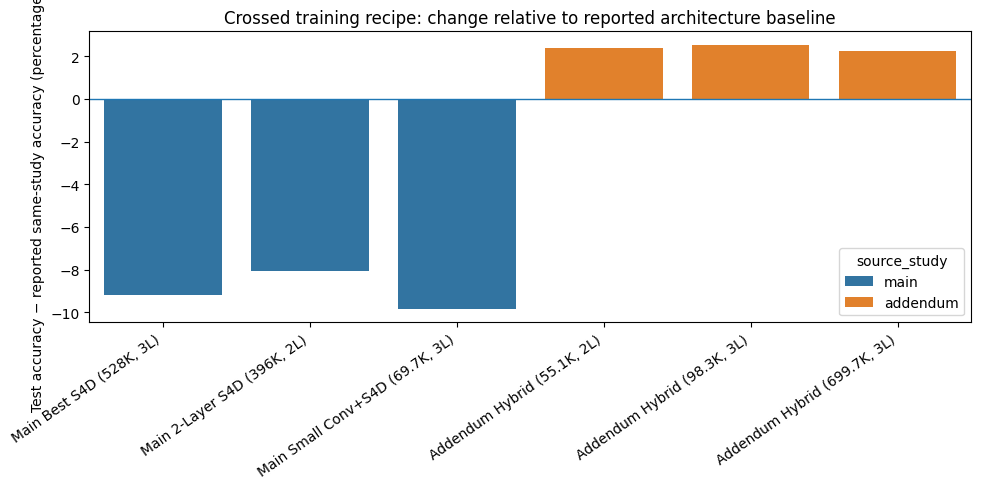

In [29]:
plt.figure(figsize=(10,5))
sns.barplot(data=crossed_df, x="label", y="delta_accuracy_pp", hue="source_study", dodge=False)
plt.axhline(0, linewidth=1)
plt.ylabel("Test accuracy − reported same-study accuracy (percentage points)")
plt.xlabel("")
plt.xticks(rotation=35, ha="right")
plt.title("Crossed training recipe: change relative to reported architecture baseline")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "crossed_recipe_accuracy_delta.png", dpi=200)
plt.show()


## 11. Package the final outputs

The notebook leaves a clean experiment directory and creates **two archives directly in `/kaggle/working`**: one containing all result artifacts and one containing all trained model weights. No restart-state files are created or archived.


In [30]:
manifest = {
    "purpose": "Test whether the main-study vs addendum accuracy difference is robust to swapping the training recipe, while restoring missing metrics for the two headline main-study rows.",
    "split_seed": SPLIT_SEED,
    "run_seeds": RUN_SEEDS,
    "planned_jobs_per_seed": 8,
    "actual_jobs": len(all_results),
    "recipes": RECIPES,
    "architectures": ARCHITECTURES,
    "job_matrix": {
        "main_architectures_under_addendum_recipe": [s["id"] for s in ARCHITECTURES if s["study"] == "main"],
        "addendum_architectures_under_main_recipe": [s["id"] for s in ARCHITECTURES if s["study"] == "addendum"],
        "main_architectures_retrained_with_main_recipe_for_missing_metrics": [s["id"] for s in ARCHITECTURES if s.get("missing_metrics")],
    },
}
(RESULTS_DIR / "experiment_manifest.json").write_text(json.dumps(manifest, indent=2))

summary = {
    "n_architectures": len(ARCHITECTURES),
    "n_crossed_runs": len(crossed_df),
    "n_missing_metric_retrains": int(len(main_metric_retrains)),
    "n_completed_runs": len(all_results),
    "mean_crossed_accuracy_delta_pp": float(crossed_df["delta_accuracy_pp"].mean()) if len(crossed_df) else None,
    "median_crossed_accuracy_delta_pp": float(crossed_df["delta_accuracy_pp"].median()) if len(crossed_df) else None,
    "n_crossed_runs_above_reported_accuracy": int((crossed_df["delta_accuracy_pp"] > 0).sum()) if len(crossed_df) else 0,
}
(RESULTS_DIR / "summary.json").write_text(json.dumps(summary, indent=2))

# Archive result artifacts only (no model weights in this archive).
RESULTS_ZIP = Path("/kaggle/working/s4d_recipe_controlled_results.zip")
WEIGHTS_ZIP = Path("/kaggle/working/s4d_recipe_controlled_weights.zip")
for archive in [RESULTS_ZIP, WEIGHTS_ZIP]:
    if archive.exists(): archive.unlink()

with zipfile.ZipFile(RESULTS_ZIP, "w", compression=zipfile.ZIP_DEFLATED) as zf:
    for path in sorted(RESULTS_DIR.rglob("*")):
        if path.is_file():
            zf.write(path, arcname=path.relative_to(OUTPUT_ROOT / "results"))

with zipfile.ZipFile(WEIGHTS_ZIP, "w", compression=zipfile.ZIP_DEFLATED) as zf:
    for path in sorted(WEIGHTS_DIR.rglob("*.pt")):
        zf.write(path, arcname=path.relative_to(WEIGHTS_DIR))

print(json.dumps(summary, indent=2))
print("\nResult archive:", RESULTS_ZIP)
print("Weight archive:", WEIGHTS_ZIP)
print("Result archive size (MB):", round(RESULTS_ZIP.stat().st_size / 1024**2, 2))
print("Weight archive size (MB):", round(WEIGHTS_ZIP.stat().st_size / 1024**2, 2))


{
  "n_architectures": 6,
  "n_crossed_runs": 6,
  "n_missing_metric_retrains": 2,
  "n_completed_runs": 8,
  "mean_crossed_accuracy_delta_pp": -3.3166666666666695,
  "median_crossed_accuracy_delta_pp": -2.900000000000002,
  "n_crossed_runs_above_reported_accuracy": 3
}

Result archive: /kaggle/working/s4d_recipe_controlled_results.zip
Weight archive: /kaggle/working/s4d_recipe_controlled_weights.zip
Result archive size (MB): 0.2
Weight archive size (MB): 9.67
